In [2]:
! pip install manim
! pip install matplotlib

In [3]:
from manim import *

import sys
sys.path.append('../framework/PythonTools')

from ParticleInitial import *
from Spacepoint import *
from Plots import *
from Wedge import *
from PoleRegion import *
from MathFunctions import *
from SpacepointGenerator import *
import random

Manim Community v0.19.0

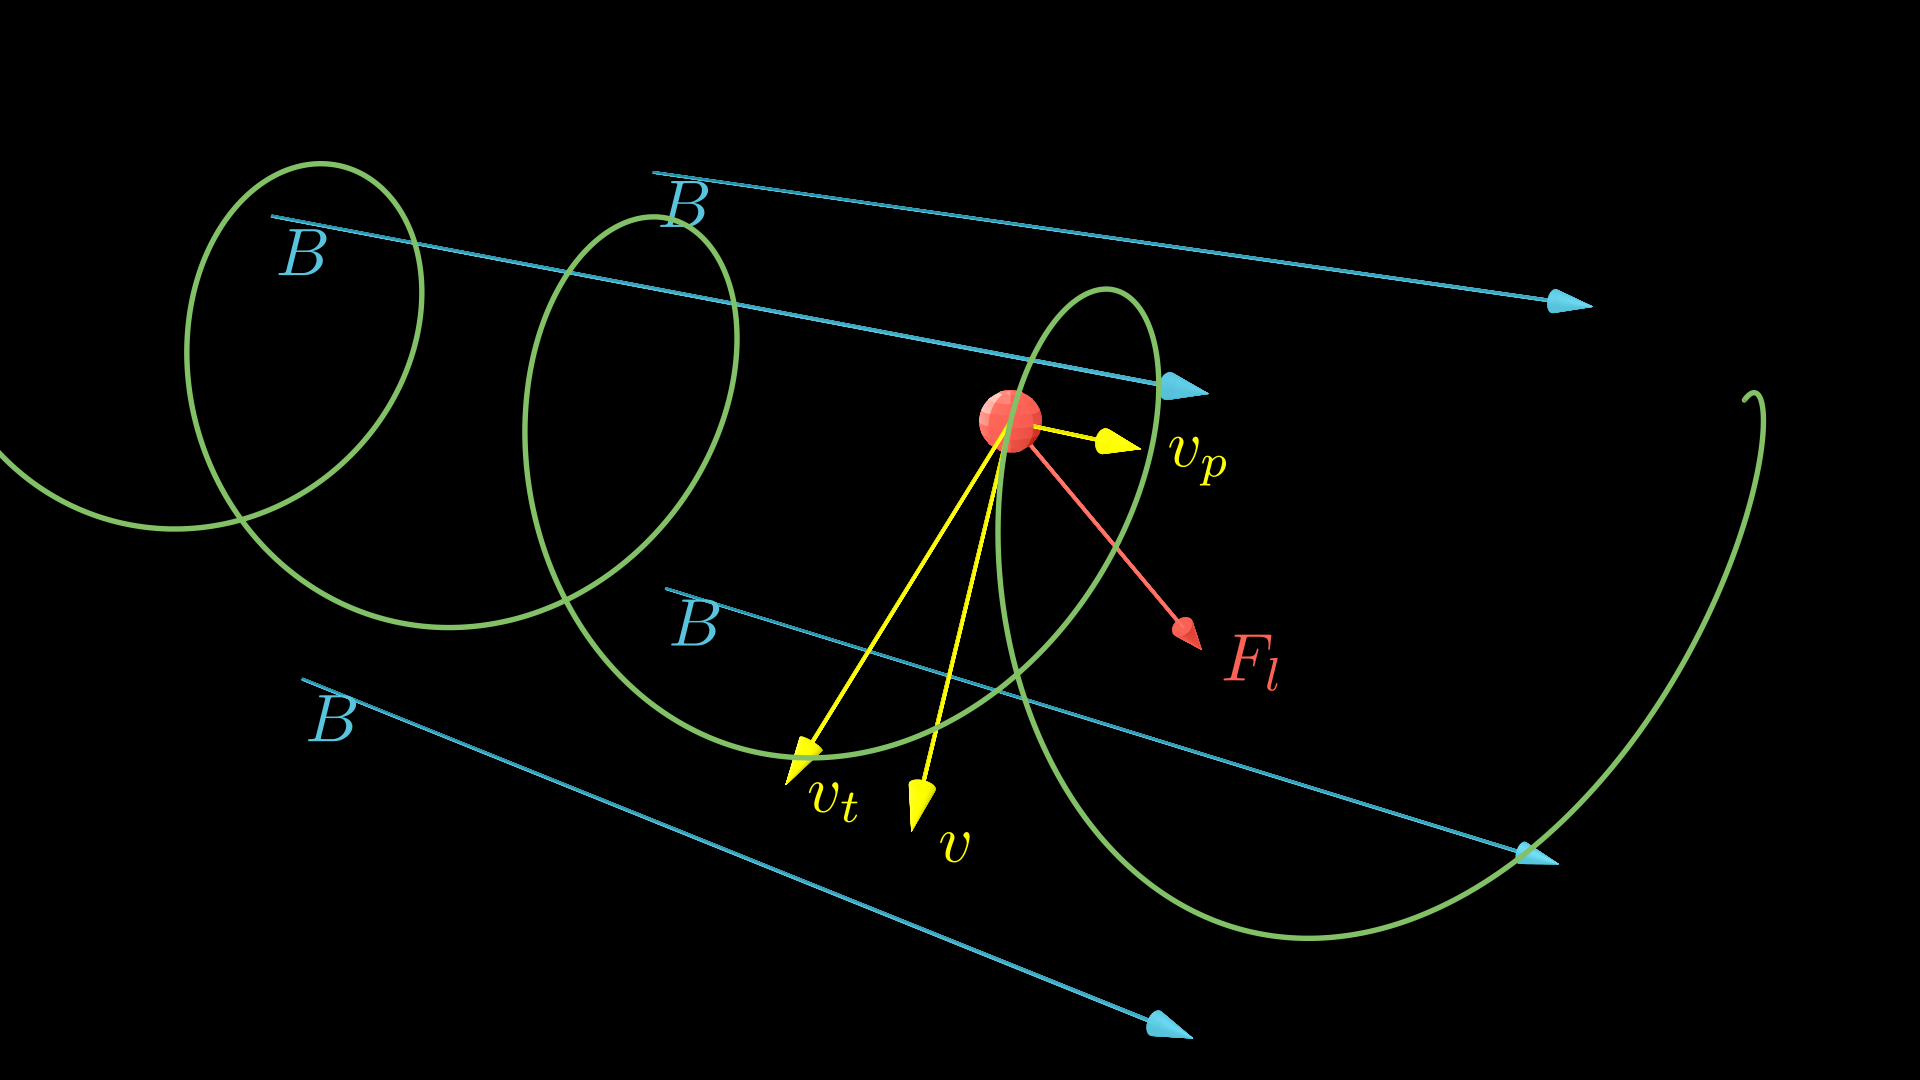

In [3]:
class ChargedParticleInMagneticField(ThreeDScene):
    def construct(self):
        font_size = 48

        # Magnetic field representation: arrow along x-axis
        B_direction = np.array([1, 0, 0])
        for y in [-2, 2]:
            for z in [-2, 2]:
                start = np.array([0, y, z]) + B_direction * -6
                end = np.array([0, y, z]) + B_direction * 4

                B_arrow = Arrow3D(start=start, end=end, color=BLUE, thickness=0.01)
                label = MathTex("B", font_size=font_size, color=BLUE).next_to(start + [0, 0, -0.25])
                self.add(B_arrow)
                self.add_fixed_orientation_mobjects(label)

        # Helical path for charged particle
        radius = 2
        pitch = 5.0
        helix = ParametricFunction(
            lambda t: np.array([
                pitch * t / (2 * PI),
                radius * np.cos(t),
                radius * np.sin(t)
            ]),
            t_range=[-5 * PI, 2.5 * PI],
            color=GREEN
        )
        self.add(helix)

        # Charged particle: a small sphere
        particle_t = PI * 6 / 8
        particle_position = np.array([pitch * particle_t / (2 * PI), radius * np.cos(particle_t), radius * np.sin(particle_t)])
        particle = Dot3D(point=particle_position, radius=0.2, color=RED)
        self.add(particle)

        # Velocity vector tangent to the helix
        velocity_vector_start = particle_position
        velocity_vector_direction = np.array([pitch / (2 * PI), radius * -np.sin(particle_t), radius * np.cos(particle_t)])
        velocity_vector_direction = velocity_vector_direction / np.linalg.norm(velocity_vector_direction)
        velocity_vector_end = particle_position + velocity_vector_direction * 3
        velocity_label = MathTex("v", font_size=font_size, color=YELLOW).next_to(velocity_vector_end + [0, 0, 0])
        velocity_arrow = Arrow3D(start=velocity_vector_start, end=velocity_vector_end, color=YELLOW, thickness=0.01)
        self.add(velocity_arrow)
        self.add_fixed_orientation_mobjects(velocity_label)

        # Velocity vector perpendicular to B
        velocity_vector_start = particle_position
        projection = velocity_vector_direction - np.dot(velocity_vector_direction, B_direction) * B_direction
        velocity_vector_end = particle_position + projection * 3
        velocity_label = MathTex(r"v_{t}", font_size=font_size, color=YELLOW).next_to(velocity_vector_end + [0, 0, 0])
        velocity_arrow = Arrow3D(start=velocity_vector_start, end=velocity_vector_end, color=YELLOW, thickness=0.01)
        self.add(velocity_arrow)
        self.add_fixed_orientation_mobjects(velocity_label)

        # Velocity vector parallel to B
        velocity_vector_start = particle_position
        projection = np.dot(velocity_vector_direction, B_direction) * B_direction
        velocity_vector_end = particle_position + projection * 3
        velocity_label = MathTex(r"v_{p}", font_size=font_size, color=YELLOW).next_to(velocity_vector_end + [0, 0, 0])
        velocity_arrow = Arrow3D(start=velocity_vector_start, end=velocity_vector_end, color=YELLOW, thickness=0.01)
        self.add(velocity_arrow)
        self.add_fixed_orientation_mobjects(velocity_label)

        # Force vector
        force_vector_start = particle_position
        force_vector_direction = -np.cross(velocity_vector_direction, B_direction)
        force_vector_end = particle_position + force_vector_direction * 3
        force_label = MathTex(r"F_{l}", font_size=font_size, color=RED).next_to(force_vector_end + [0, 0, 0])
        force_arrow = Arrow3D(start=force_vector_start, end=force_vector_end, color=RED, thickness=0.01)
        self.add(force_arrow)
        self.add_fixed_orientation_mobjects(force_label)


        # Set camera orientation for a clear static view
        self.set_camera_orientation(phi=75 * DEGREES, theta=-45 * DEGREES)

%manim -qh -v WARNING ChargedParticleInMagneticField

In [4]:
particles_initial = ParticleInitial.read_from_csv('../data/odd_output_ttbar_PU200_100/particles_initial.csv')
print(particles_initial[0])

spacepoints = Spacepoint.read_from_csv('../data/odd_output_ttbar_PU200_100/spacepoints.csv')
print(spacepoints[0])

ParticleInitial(event_id=0, particle_id=4503599711256576, particle_type=211, process=0, vx=-0.00687793, vy=0.00644291, vz=26.2993, vt=6.84225, px=-0.190902, py=0.241511, pz=0.683707, m=0.13957, q=1.0, eta=1.53828, phi=2.23969, pt=0.307849, p=0.749818, vertex_primary_id=1, vertex_secondary_id=0, generation=5, sub_particle_id=0)
Spacepoint(event_id=0, measurement_id=0, geometry_id=6402, x=170.382, y=-15.7202, z=-1523.2, var_r=0.0009, var_z=8.43615e-37)


In [5]:
print(f"number of particles: {len(particles_initial)},\taverage per event: {len(particles_initial) / 20}")
print(f"number of spacepoints: {len(spacepoints)},\taverage per event: {len(spacepoints) / 20}")

number of particles: 95639,	average per event: 4781.95
number of spacepoints: 1239659,	average per event: 61982.95


First cluster: 4657
Second cluster: 383


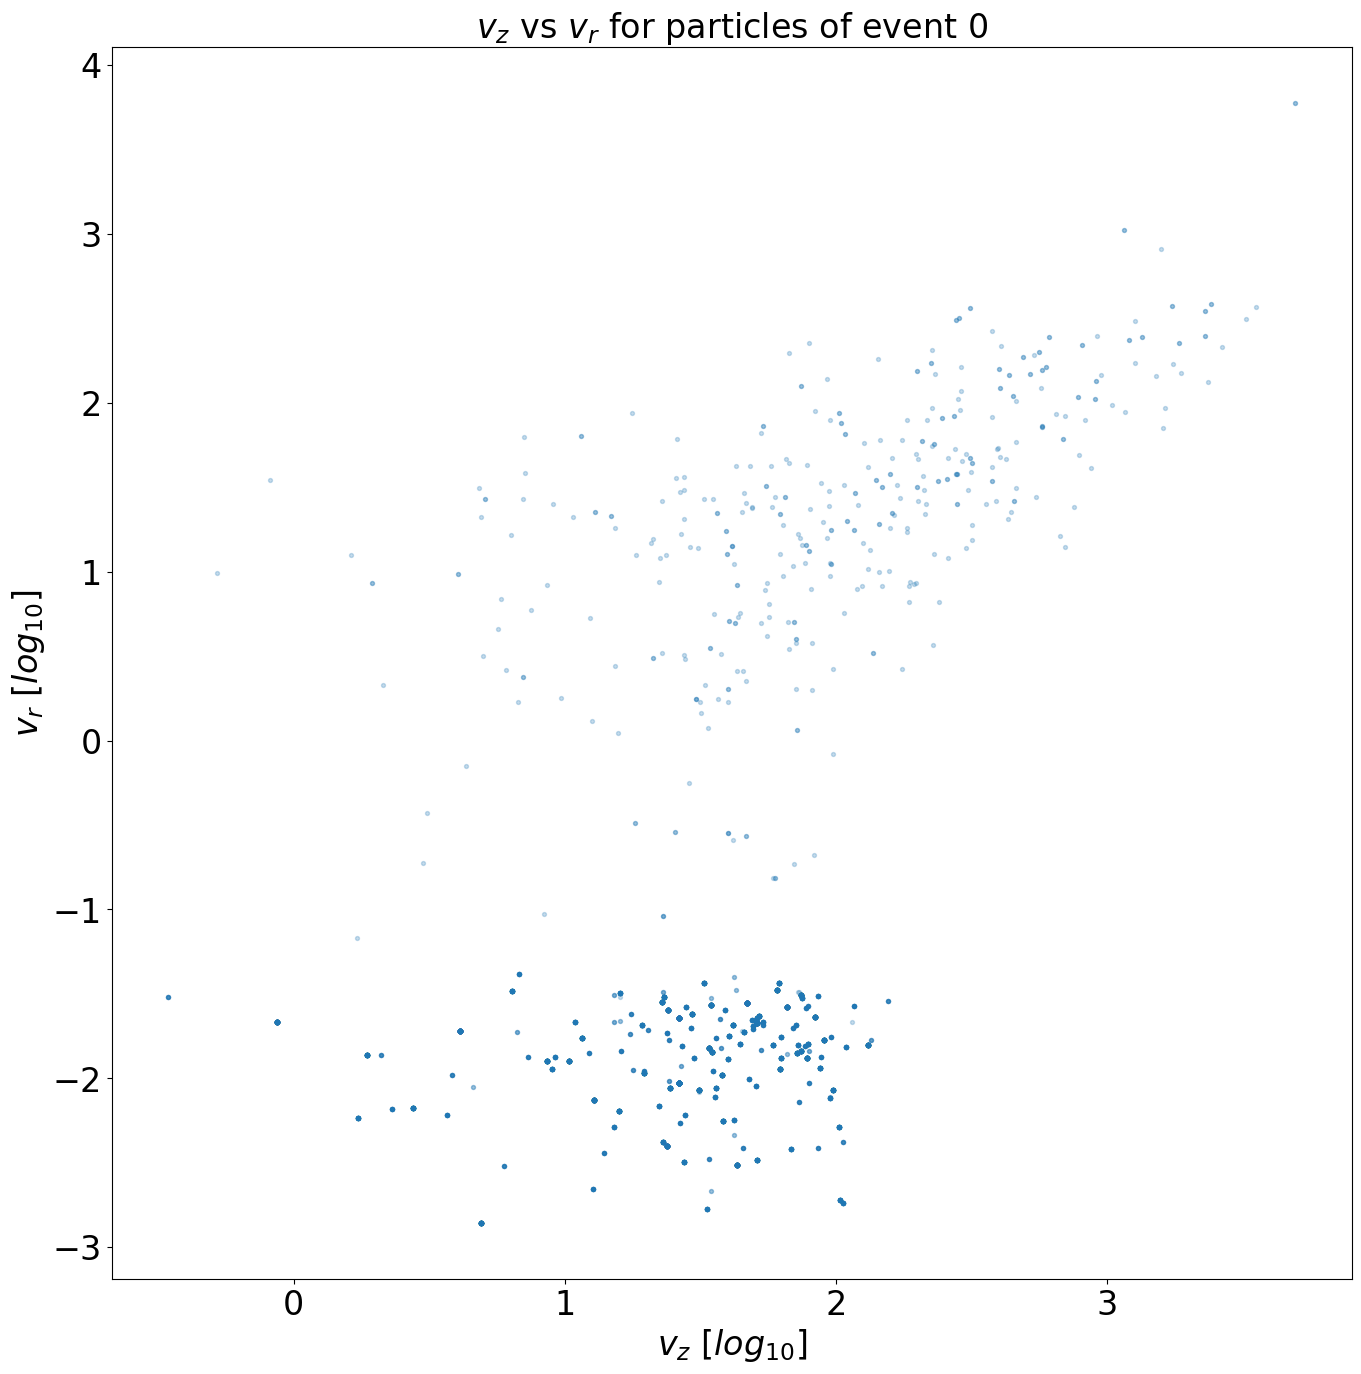

In [8]:
vrs = [math.log10(math.sqrt(p.vx ** 2 + p.vy ** 2)) for p in particles_initial if p.event_id == 0]
vzs = [math.log10(abs(p.vz)) for p in particles_initial if p.event_id == 0]

print(f"First cluster: {len([p for p in particles_initial if p.event_id == 0 and math.log10(math.sqrt(p.vx ** 2 + p.vy ** 2)) < 0.1 and math.log10(abs(p.vz)) < 200])}")
print(f"Second cluster: {len([p for p in particles_initial if p.event_id == 0 and math.log10(math.sqrt(p.vx ** 2 + p.vy ** 2)) >= 0.1 or math.log10(abs(p.vz)) >= 200])}")

plt.figure(figsize=(16, 16))
plt.scatter(vzs, vrs, color="tab:blue", s=8, alpha=0.25)
plt.xlabel("$v_z$ [$log_{10}$]", fontsize=24)
plt.ylabel("$v_r$ [$log_{10}$]", fontsize=24)
plt.title("$v_z$ vs $v_r$ for particles of event 0", fontsize=24)
plt.tick_params(labelsize=24)
plt.show()

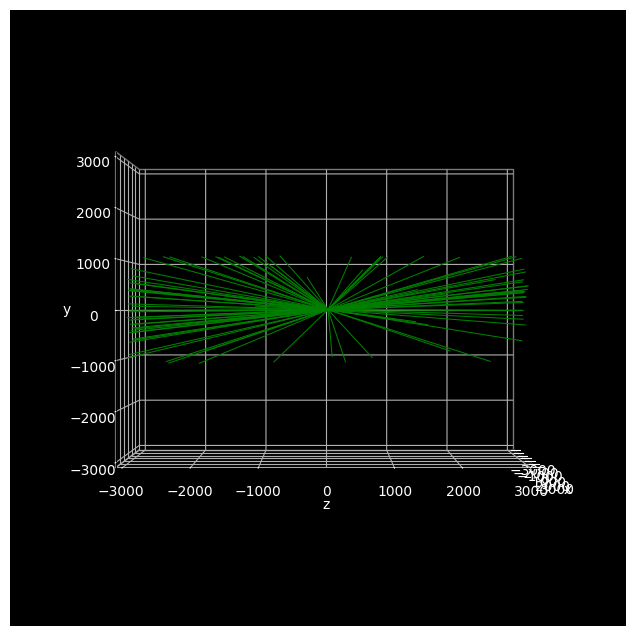

In [8]:
particles_filtered = [p for p in particles_initial if math.sqrt(p.vx**2 + p.vy**2) < 1000 and abs(p.vz) < 3000]

perspective = {'elev': 0, 'azim': 0, 'roll': 0}
detector_plot = DetectorPlot(max_abs_xy=1100, max_abs_z=3100, perspective=perspective, figure_size=(8, 8), keep_aspect_ratio=True)
detector_plot.plot_particles((particles_filtered[:100]), size=0.75)

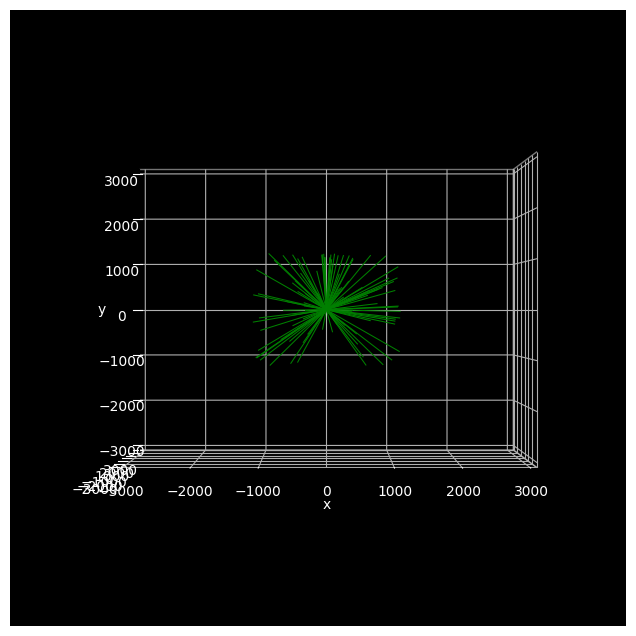

In [9]:
perspective = {'elev': 0, 'azim': -90, 'roll': 0}
detector_plot = DetectorPlot(max_abs_xy=1100, max_abs_z=3100, perspective=perspective, figure_size=(8, 8), keep_aspect_ratio=True)
detector_plot.plot_particles((particles_filtered[:100]), size=0.75)

number of spacepoints: 65279


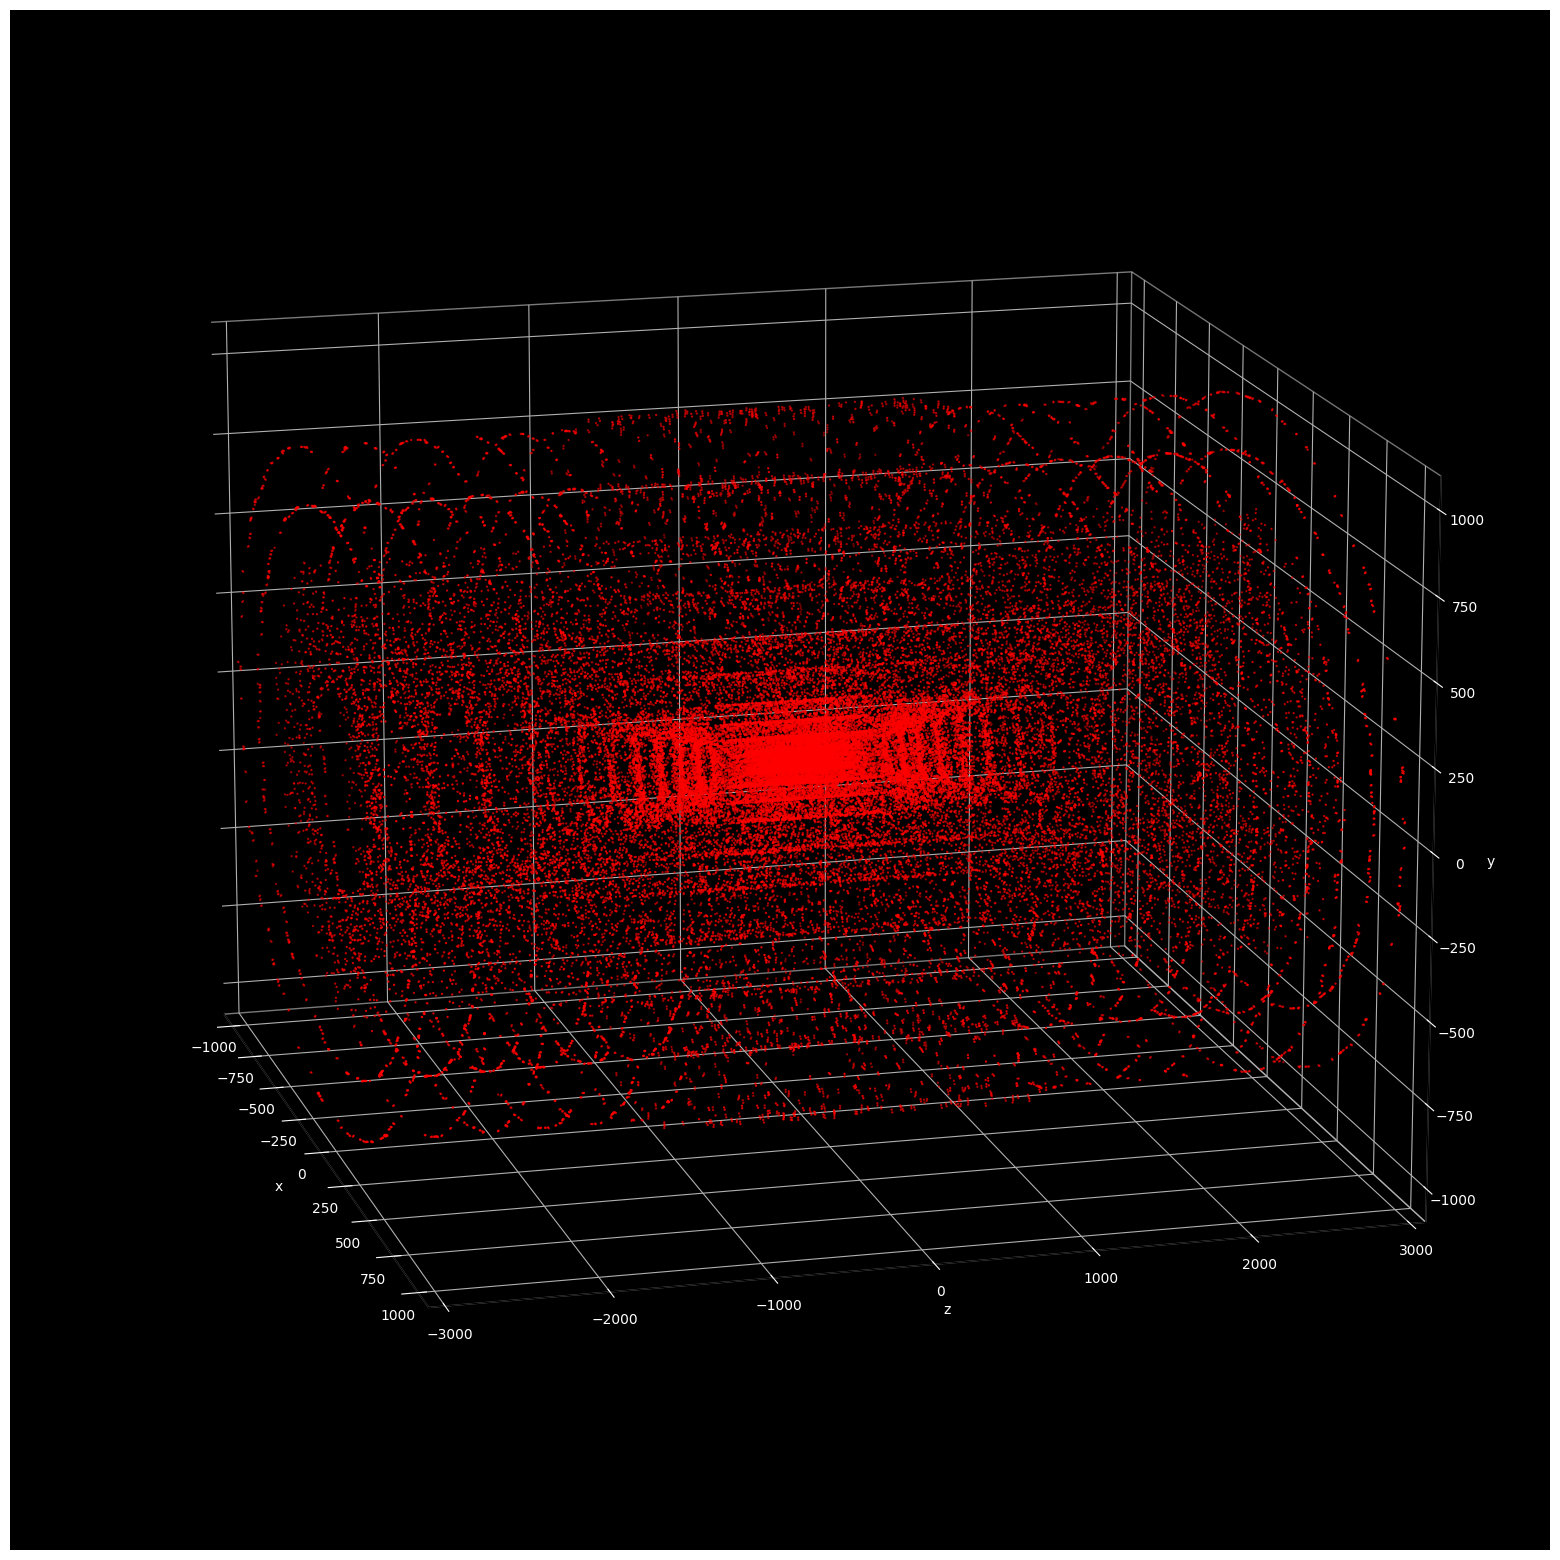

In [10]:
spacepoints_filtered = [s for s in spacepoints if s.event_id == 0]
print(f"number of spacepoints: {len(spacepoints_filtered)}")

perspective = {'elev': 15, 'azim': -15, 'roll': 0}
detector_plot = DetectorPlot(max_abs_xy=1100, max_abs_z=3100, perspective=perspective, figure_size=(20, 20), keep_aspect_ratio=False)
detector_plot.plot_spacepoints(spacepoints_filtered, size=0.5)

Manim Community v0.19.0

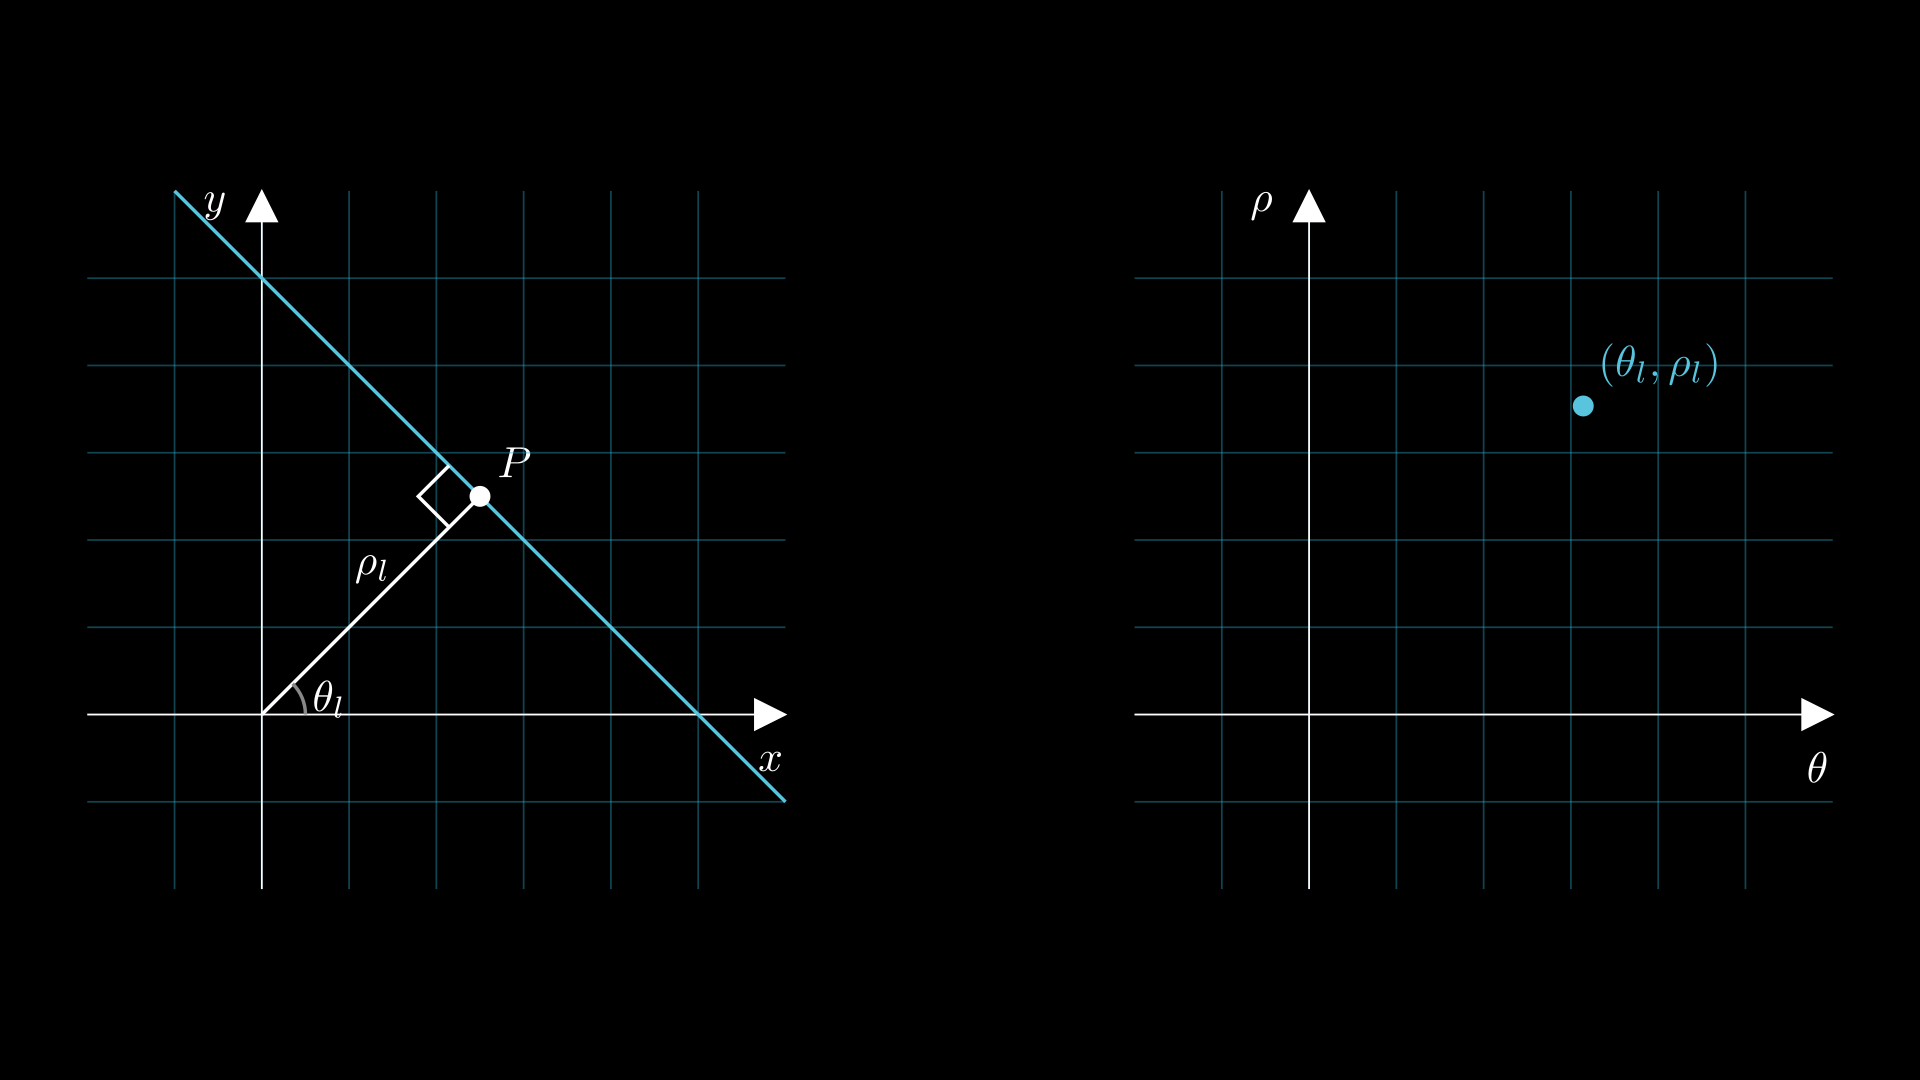

In [11]:
config.frame_width = 22
config.frame_height = 10

class HoughTransformLine(Scene):
    def construct(self):
        # Create two coordinate systems side by side
        xy_plane = NumberPlane(
            x_range=[-2, 6, 1],
            y_range=[-2, 6, 1],
            x_length=8,
            y_length=8,
            background_line_style={
                "stroke_opacity": 0.4
            },
            axis_config={
                "include_tip": True,
                "color": WHITE
            }
        ).shift(LEFT * 6)

        hough_plane = NumberPlane(
            x_range=[-2, 6, 1],
            y_range=[-2, 6, 1],
            x_length=8,
            y_length=8,
            background_line_style={
                "stroke_opacity": 0.4
            },
            axis_config={
                "include_tip": True,
                "color": WHITE
            }
        ).shift(RIGHT * 6)

        # Add axes labels
        xy_labels = VGroup(
            # next to tip
            MathTex("x").next_to(xy_plane.x_axis.get_tip(), DOWN),
            MathTex("y").next_to(xy_plane.y_axis.get_tip(), LEFT)
        )

        hough_labels = VGroup(
            MathTex("\\theta").next_to(hough_plane.x_axis.get_tip(), DOWN),
            MathTex("\\rho").next_to(hough_plane.y_axis.get_tip(), LEFT)
        )

        # Create the line in xy-space
        line_start = xy_plane.c2p(-1, 6)
        line_end = xy_plane.c2p(6, -1)
        line = Line(line_start, line_end, color=BLUE)

        # Create perpendicular line and point P
        origin = xy_plane.c2p(0, 0)
        p_coords = xy_plane.c2p(2.5, 2.5)  # Point on the line
        point_p = Dot(p_coords, color=WHITE).scale(1.5)
        perp_line = Line(
            origin,
            p_coords,
            color=WHITE
        )

        # Add perpendicular line label next to the middle of the line
        perp_line_label = MathTex("\\rho_l").next_to((origin + p_coords) / 2, UP, buff=0.25)

        # Add angles
        angle_theta = Angle(
            Line(origin, xy_plane.c2p(1, 0)),
            perp_line,
            radius=0.5,
            color=GRAY
        )
        theta_label = MathTex("\\theta_l").next_to(angle_theta, RIGHT, buff=0.1)

        # Add right angle next to line and perpendicular line
        right_angle = RightAngle(perp_line, line, length=0.5, quadrant=[-1, -1], color=WHITE)

        # Add P label
        p_label = MathTex("P").next_to(point_p, UR, buff=0.1)
        self.add(p_label)

        # Point in Hough space
        theta = np.arctan2(xy_plane.p2c(p_coords)[1], xy_plane.p2c(p_coords)[0]) * 4
        rho = np.sqrt(xy_plane.p2c(p_coords)[0]**2 + xy_plane.p2c(p_coords)[1]**2)
        hough_point = Dot(
            hough_plane.c2p(theta, rho),
            color=BLUE
        ).scale(1.5)
        hough_coords = MathTex("(\\theta_l, \\rho_l)").next_to(hough_point, UR, buff=0.1).set_color(BLUE)

        # Add all elements to the scene
        self.add(xy_plane, hough_plane)
        self.add(xy_labels, hough_labels)
        self.add(line, point_p, perp_line)
        self.add(perp_line_label)
        self.add(right_angle)
        self.add(angle_theta, theta_label)
        self.add(hough_point, hough_coords)


%manim -qh -v WARNING HoughTransformLine


Manim Community v0.19.0

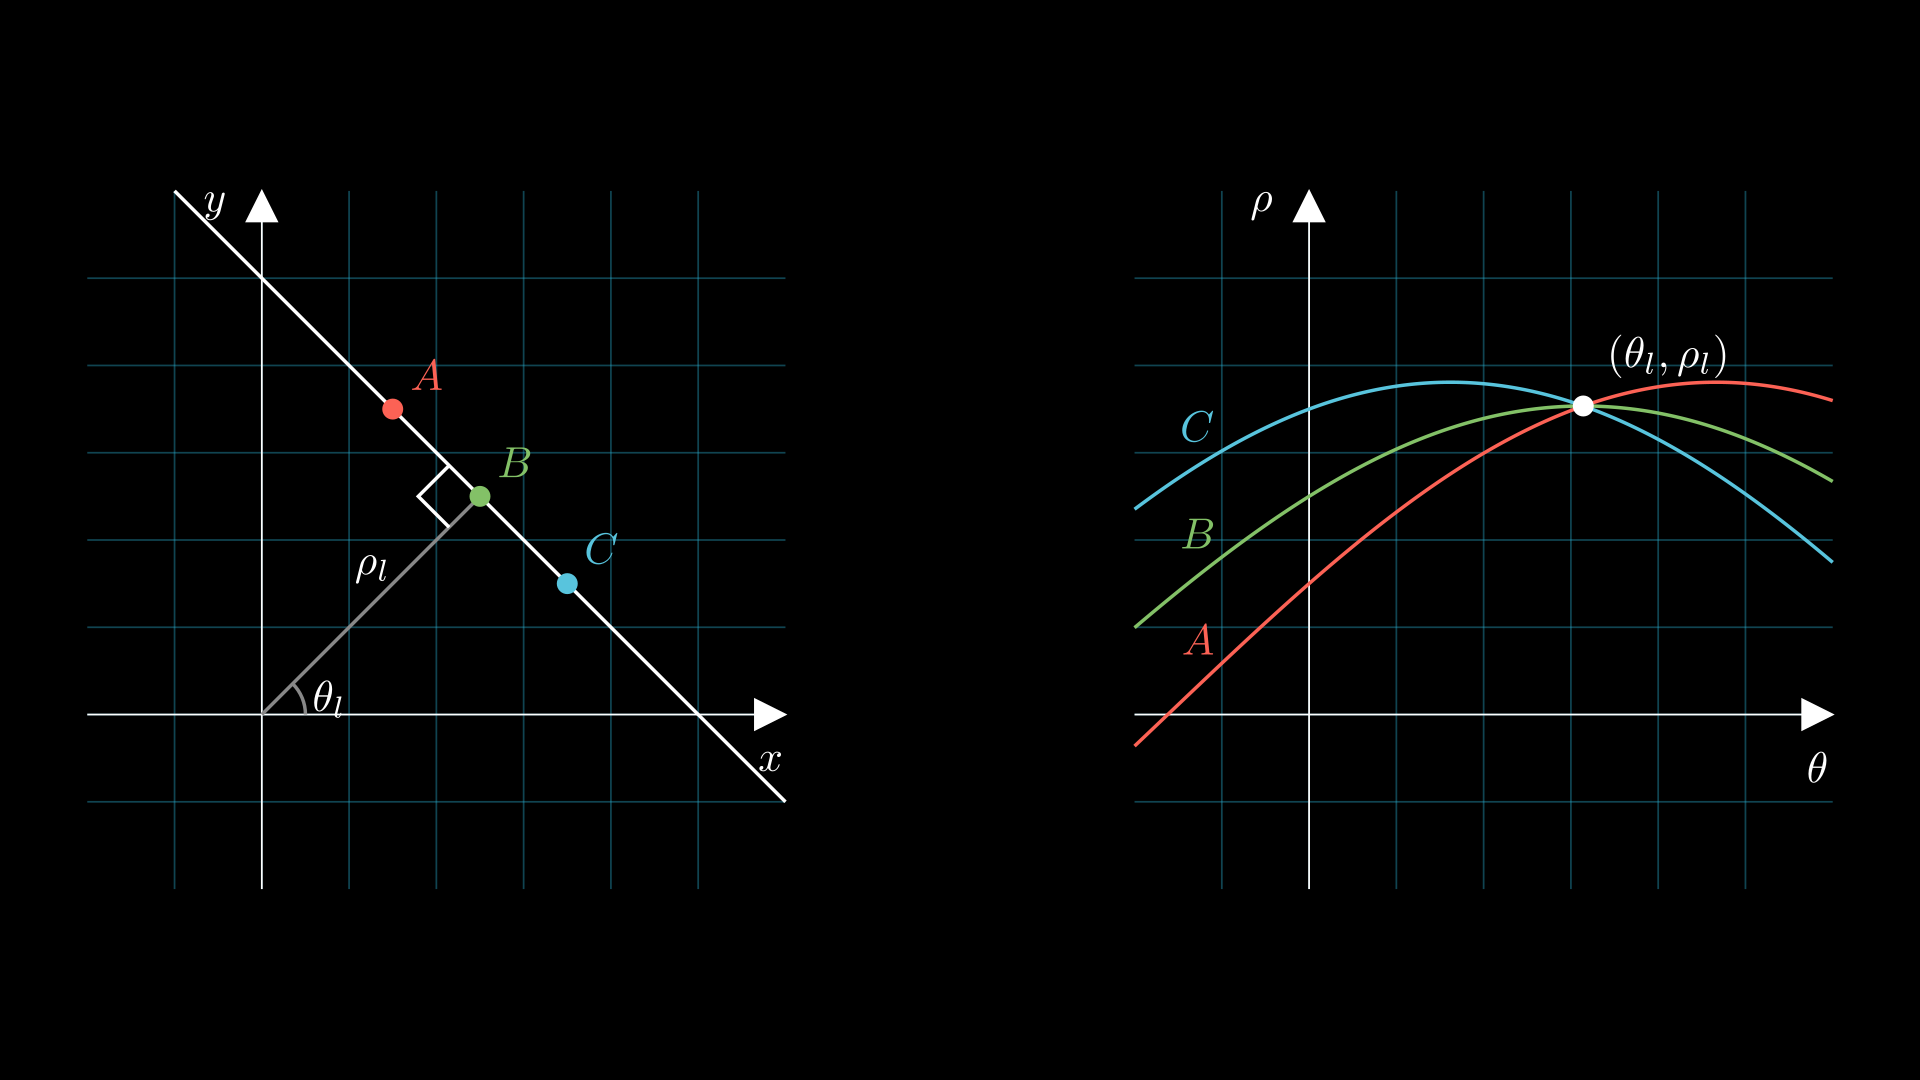

In [12]:
config.frame_width = 22
config.frame_height = 10

class HoughTransformLineAndPoints(Scene):
    def construct(self):
        # Create two coordinate systems side by side
        xy_plane = NumberPlane(
            x_range=[-2, 6, 1],
            y_range=[-2, 6, 1],
            x_length=8,
            y_length=8,
            background_line_style={
                "stroke_opacity": 0.4
            },
            axis_config={
                "include_tip": True,
                "color": WHITE
            }
        ).shift(LEFT * 6)

        hough_plane = NumberPlane(
            x_range=[-2, 6, 1],
            y_range=[-2, 6, 1],
            x_length=8,
            y_length=8,
            background_line_style={
                "stroke_opacity": 0.4
            },
            axis_config={
                "include_tip": True,
                "color": WHITE
            }
        ).shift(RIGHT * 6)

        # Add axes labels
        xy_labels = VGroup(
            # next to tip
            MathTex("x").next_to(xy_plane.x_axis.get_tip(), DOWN),
            MathTex("y").next_to(xy_plane.y_axis.get_tip(), LEFT)
        )

        hough_labels = VGroup(
            MathTex("\\theta").next_to(hough_plane.x_axis.get_tip(), DOWN),
            MathTex("\\rho").next_to(hough_plane.y_axis.get_tip(), LEFT)
        )

        # Create the line in xy-space
        line_start = xy_plane.c2p(-1, 6)
        line_end = xy_plane.c2p(6, -1)
        line = Line(line_start, line_end, color=WHITE)

        # Create perpendicular line and point P
        origin = xy_plane.c2p(0, 0)
        p_coords = xy_plane.c2p(2.5, 2.5)  # Point on the line
        perp_line = Line(
            origin,
            p_coords,
            color=GRAY
        )

        # Add perpendicular line label next to the middle of the line
        perp_line_label = MathTex("\\rho_l").next_to((origin + p_coords) / 2, UP, buff=0.25)

        # Add angles
        angle_theta = Angle(
            Line(origin, xy_plane.c2p(1, 0)),
            perp_line,
            radius=0.5,
            color=GRAY
        )
        theta_label = MathTex("\\theta_l").next_to(angle_theta, RIGHT, buff=0.1)

        # Add right angle next to line and perpendicular line
        right_angle = RightAngle(perp_line, line, length=0.5, quadrant=[-1, -1], color=WHITE)

        # Point in Hough space
        theta = np.arctan2(xy_plane.p2c(p_coords)[1], xy_plane.p2c(p_coords)[0]) * 4
        rho = np.sqrt(xy_plane.p2c(p_coords)[0]**2 + xy_plane.p2c(p_coords)[1]**2)
        hough_point = Dot(
            hough_plane.c2p(theta, rho),
            color=WHITE
        ).scale(1.5)
        hough_coords = MathTex("(\\theta_l, \\rho_l)").next_to(hough_point, UR, buff=0.2)

        # Add points A, B, C and labels for them
        points = VGroup(
            Dot(xy_plane.c2p(1.5, 3.5), color=RED).scale(1.5),
            Dot(xy_plane.c2p(2.5, 2.5), color=GREEN).scale(1.5),
            Dot(xy_plane.c2p(3.5, 1.5), color=BLUE).scale(1.5),
        )
        points_labels = VGroup(
            MathTex("A").next_to(points[0], UR, buff=0.1).set_color(RED),
            MathTex("B").next_to(points[1], UR, buff=0.1).set_color(GREEN),
            MathTex("C").next_to(points[2], UR, buff=0.1).set_color(BLUE)
        )

        # Add A, B, C functions in Hough space
        def get_hough_function(point):
            def hough_function(theta):
                rho = point[0] * np.cos(theta / 4) + point[1] * np.sin(theta / 4)
                return hough_plane.c2p(theta, rho)[1]
            return hough_function
        
        points_hough = VGroup(
            FunctionGraph(
                get_hough_function((1.5, 3.5)),
                x_range=[-2, 6],
                color=RED
            ),
            FunctionGraph(
                get_hough_function((2.5, 2.5)),
                x_range=[-2, 6],
                color=GREEN
            ),
            FunctionGraph(
                get_hough_function((3.5, 1.5)),
                x_range=[-2, 6],
                color=BLUE
            )
        ).shift(RIGHT * 4)

        # Add A, B, C labels in Hough space
        points_hough_labels = VGroup(
            MathTex("A").next_to(np.array([-1, get_hough_function((1.5, 3.5))(-1), 0]), UL, buff=0.1).set_color(RED),
            MathTex("B").next_to(np.array([-1, get_hough_function((2.5, 2.5))(-1), 0]), UL, buff=0.1).set_color(GREEN),
            MathTex("C").next_to(np.array([-1, get_hough_function((3.5, 1.5))(-1), 0]), UL, buff=0.1).set_color(BLUE)
        ).shift(RIGHT * 4)

        # Add all elements to the scene
        self.add(xy_plane, hough_plane)
        self.add(xy_labels, hough_labels)
        self.add(line, perp_line)
        self.add(perp_line_label)
        self.add(right_angle)
        self.add(angle_theta, theta_label)
        self.add(points)
        self.add(points_labels)
        self.add(points_hough)
        self.add(points_hough_labels)
        self.add(hough_point, hough_coords)


%manim -qh -v WARNING HoughTransformLineAndPoints


Manim Community v0.19.0

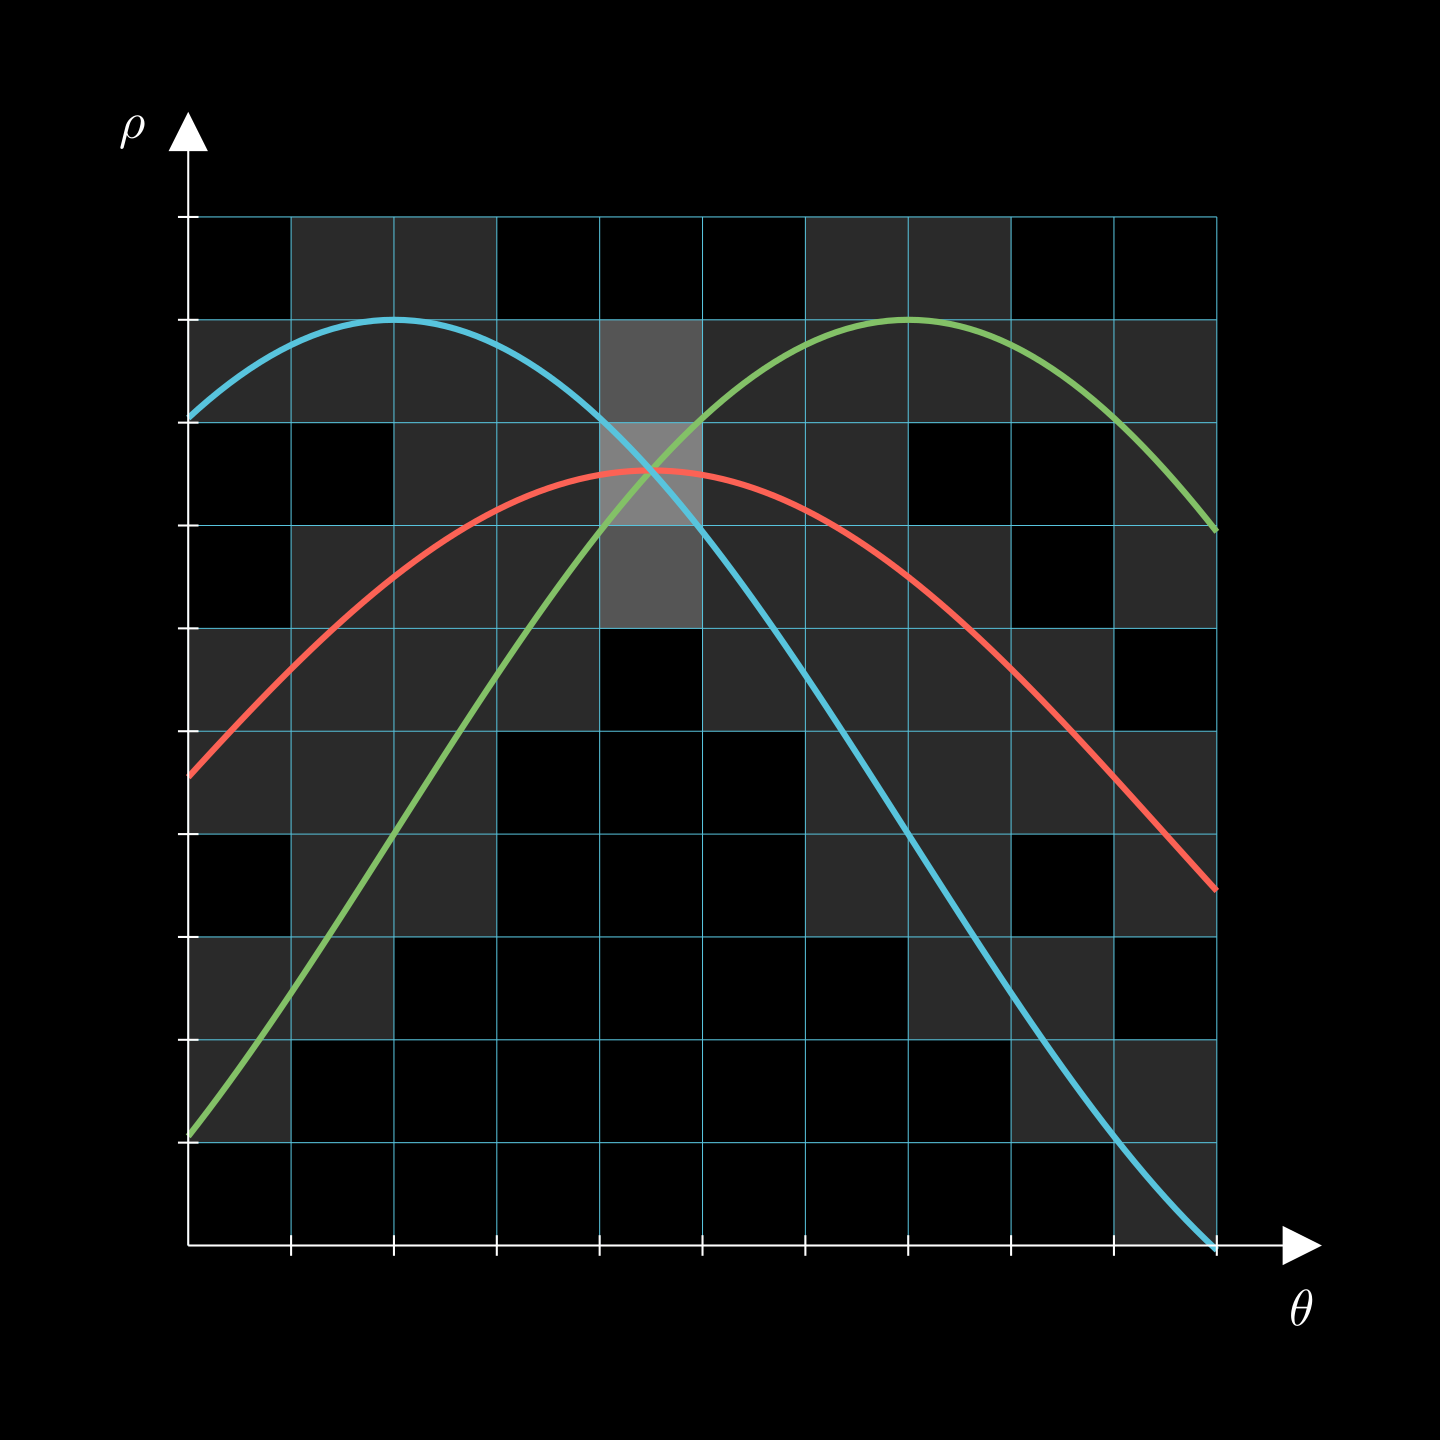

In [13]:
config.frame_width = 14
config.frame_height = 14

class HoughAccumulatorIllustration(Scene):
    def construct(self):
        # Editable parameters
        num_bins = 10
        theta_min = 0
        theta_max = 10
        rho_min = 0
        rho_max = 10
        colors = [GREEN, RED, BLUE]  # Colors for curves A, B, C
        labels = ["A", "B", "C"]

        # Set up axes with unit size 1 for simplicity
        axes = Axes(
            x_range=[theta_min, theta_max + 1],
            y_range=[rho_min, rho_max + 1],
            x_length=theta_max - theta_min + 1,
            y_length=rho_max - rho_min + 1,
            # axis_config={"color": WHITE, "include_tip": True},
        )

        def get_hough_function(point):
            def hough_function(theta):
                theta = (theta - 2) / 10 * PI
                rho = point[0] * np.cos(theta) + point[1] * np.sin(theta) + 4
                return rho
            return hough_function

        original_points = [(0, 5), (2.5, 2.5), (5, 0)]
        hough_points = [get_hough_function((x, y)) for (x, y) in original_points]

        # Fill accumulator
        accumulator = np.zeros((num_bins, num_bins))
        for func in hough_points:
            for i in range(num_bins):
                for j in range(num_bins):
                    d_theta = (theta_max - theta_min) / num_bins
                    d_rho = (rho_max - rho_min) / num_bins

                    theta_left = theta_min + i * d_theta
                    theta_right = theta_min + (i + 1) * d_theta
                    rho_bottom = rho_min + j * d_rho
                    rho_top = rho_min + (j + 1) * d_rho

                    hit = False
                    hit = hit or (func(theta_left) >= rho_bottom and func(theta_left) <= rho_top)
                    hit = hit or (func(theta_right) >= rho_bottom and func(theta_right) <= rho_top)
                    hit = hit or (func(theta_left) <= rho_bottom and func(theta_right) >= rho_bottom)
                    hit = hit or (func(theta_left) >= rho_top and func(theta_right) <= rho_top)
                    if hit:
                        accumulator[i, j] += 1

        # Create filled cells for accumulator
        cells = VGroup()
        for i in range(num_bins):
            for j in range(num_bins):
                vote = accumulator[i, j]
                if vote > 0:
                    intensity = vote / 6
                else:
                    intensity = 0
                cell_color = interpolate_color(BLACK, WHITE, intensity)
                rect = Rectangle(
                    width=d_theta,
                    height=d_rho,
                    fill_color=cell_color,
                    fill_opacity=1,
                    stroke_width=0
                )
                rect.move_to(axes.c2p(
                    theta_min + (i + 0.5) * d_theta,
                    rho_min + (j + 0.5) * d_rho
                ))
                cells.add(rect)

        scene_group = VGroup()
        scene_group.add(cells)

        # Add grid lines
        grid = VGroup()
        # Horizontal lines
        for j in range(num_bins + 1):
            rho = rho_min + j * d_rho
            line = Line(
                axes.c2p(theta_min, rho),
                axes.c2p(theta_max, rho),
                color=BLUE,
                stroke_width=1
            )
            grid.add(line)
        # Vertical lines
        for i in range(num_bins + 1):
            theta = theta_min + i * d_theta
            line = Line(
                axes.c2p(theta, rho_min),
                axes.c2p(theta, rho_max),
                color=BLUE,
                stroke_width=1
            )
            grid.add(line)
        scene_group.add(grid)

        hough_point_graphs = VGroup()
        for i, func in enumerate(hough_points):
            hough_point_graphs.add(axes.plot(func, x_range=[theta_min, theta_max], color=colors[i], stroke_width=6))
        scene_group.add(hough_point_graphs)

        # Labels for axes
        theta_label = MathTex(r"\theta").next_to(axes.get_x_axis().get_tip(), DOWN)
        rho_label = MathTex(r"\rho").next_to(axes.get_y_axis().get_tip(), LEFT)
        scene_group.add(axes, theta_label, rho_label)

        scene_group.center()
        self.add(scene_group)

%manim -qh -r 1440,1440 -v WARNING HoughAccumulatorIllustration

Manim Community v0.19.0

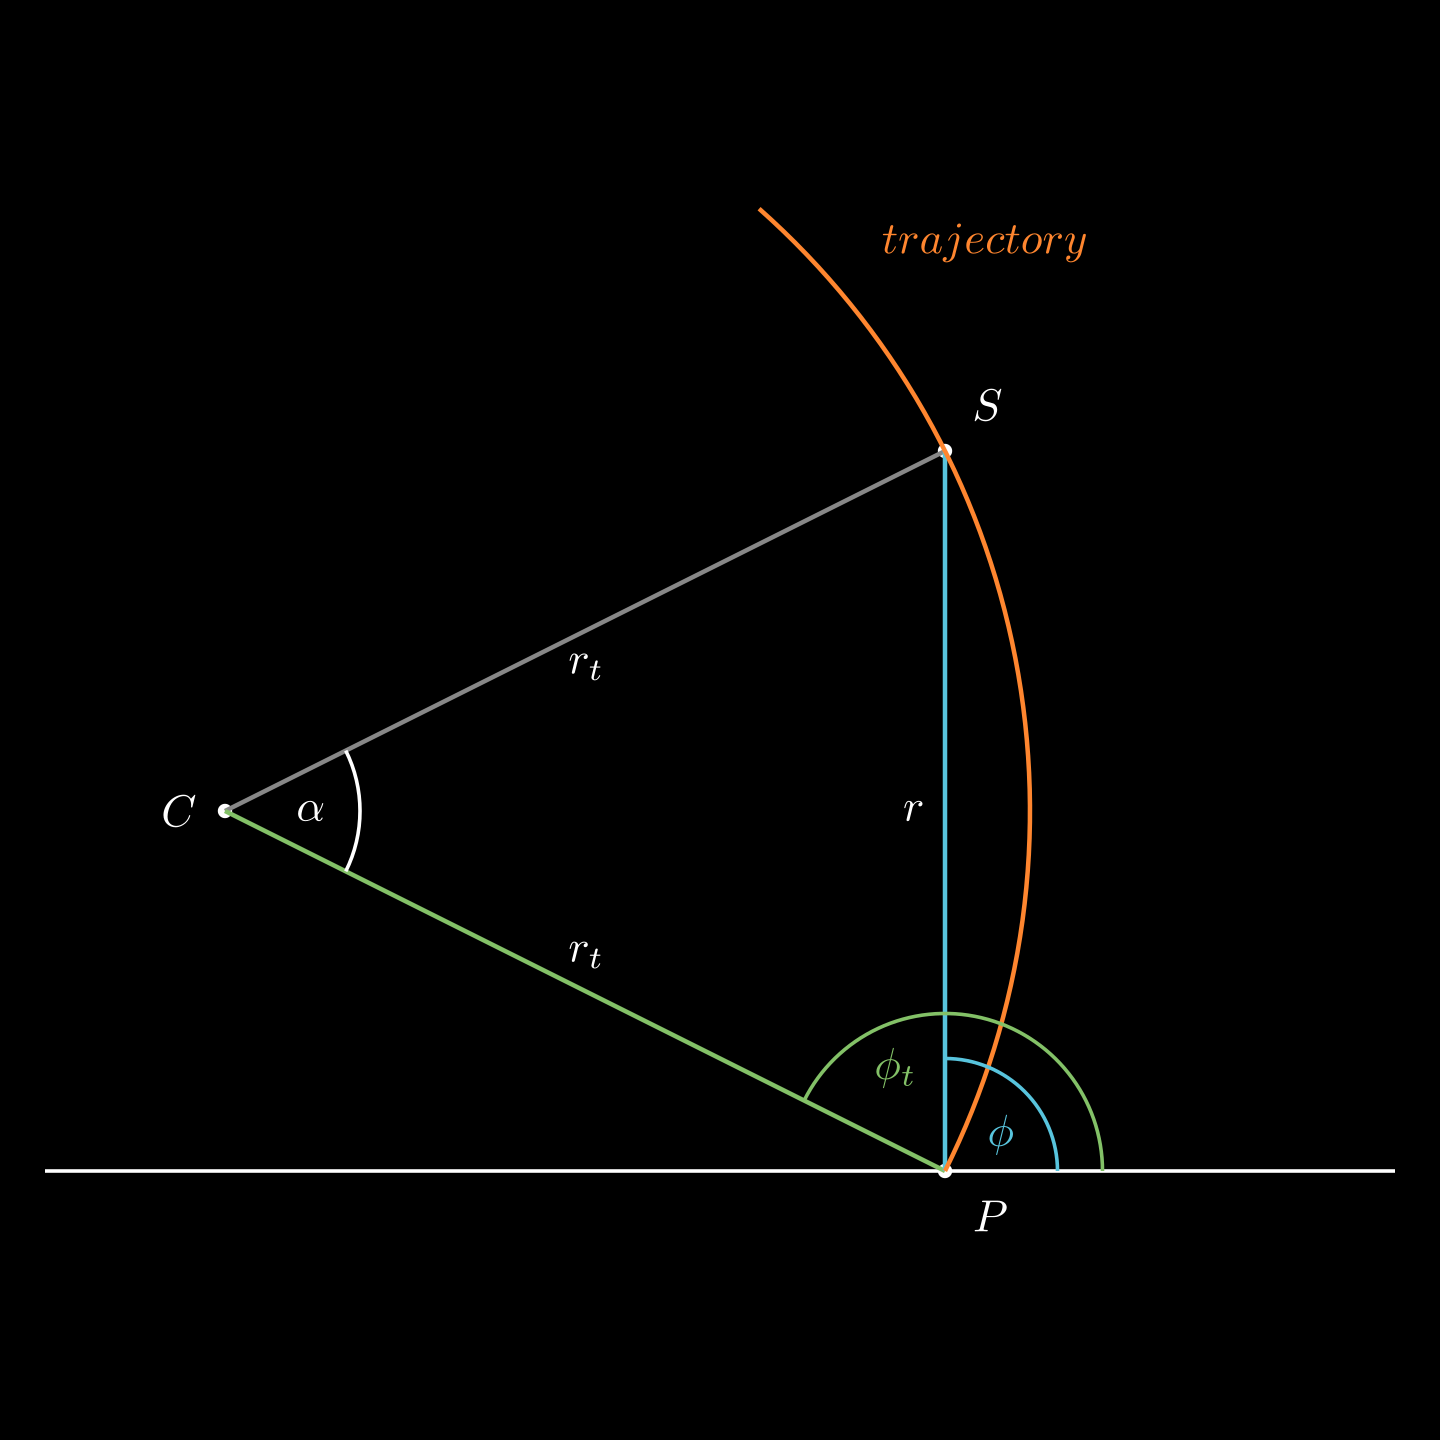

In [14]:
config.frame_width = 16
config.frame_height = 16

class TrajectoryInXYPlane(Scene):
    def construct(self):
        scene_group = VGroup()
        
        # X-axis
        x_axis = Line(start=LEFT * 10, end=RIGHT * 5, color=WHITE)
        scene_group.add(x_axis)

        # Points
        p_coords = np.array([0, 0, 0])
        s_coords = np.array([0, 8, 0])
        c_coords = np.array([-8, 4, 0])

        p = Dot(p_coords, color=WHITE)
        p_label = MathTex("P").next_to(p, DR)
        scene_group.add(p, p_label)

        c = Dot(c_coords, color=WHITE)
        c_label = MathTex("C").next_to(c, LEFT)
        scene_group.add(c, c_label)

        s = Dot(s_coords, color=WHITE)
        s_label = MathTex("S").next_to(s, UR)
        scene_group.add(s, s_label)

        # Lines: CS, CP, SP
        cp = Line(p_coords, c_coords, color=GREEN, stroke_width=5)
        r_t_label = MathTex(r"r_t").next_to(cp.get_midpoint(), UP, buff=0.25)

        cs = Line(c_coords, s_coords, color=GRAY, stroke_width=5)
        r_t_label_2 = MathTex(r"r_t").next_to(cs.get_midpoint(), DOWN, buff=0.25)

        sp = Line(s_coords, p_coords, color=BLUE, stroke_width=5)
        r_label = MathTex(r"r").next_to(sp.get_midpoint(), LEFT, buff=0.25)

        scene_group.add(cs, cp, sp, r_t_label, r_t_label_2, r_label)

        # Arc from P to some point
        r_t = np.linalg.norm(c_coords - ORIGIN)
        angle_start = np.arctan2(p_coords[1] - c_coords[1], p_coords[0] - c_coords[0])
        arc_angle = 75 * DEGREES
        arc = Arc(
            radius=r_t,
            arc_center=c_coords,
            start_angle=angle_start,
            angle=arc_angle,
            color=ORANGE,
            stroke_width=5
        )
        trajectory_label = MathTex("trajectory").next_to(arc.get_center() + np.array([1, 4.5, 0]), UP)
        trajectory_label.set_color(ORANGE)
        scene_group.add(arc, trajectory_label)

        # Angle phi_t at P for CP direction
        phi_t_angle = Angle(x_axis, cp, radius=1.75, color=GREEN)
        phi_t_label = MathTex(r"\phi_t").next_to(phi_t_angle.get_center() + np.array([-0.2, -0.2, 0]), UL)
        phi_t_label.set_color(GREEN)
        scene_group.add(phi_t_angle, phi_t_label)

        # Angle phi (perhaps phi_s at P for PS)
        ps = Line(ORIGIN, s_coords, color=GRAY)
        phi_angle = Angle(x_axis, ps, radius=1.25, color=BLUE)
        phi_label = MathTex(r"\phi").next_to(phi_angle.get_center(), DOWN, buff=0)
        phi_label.set_color(BLUE)
        scene_group.add(phi_angle, phi_label)

        # Angle alpha at C
        alpha_angle = Angle(cp, cs, radius=1.5, color=WHITE, quadrant=(-1, 1))
        alpha_label = MathTex(r"\alpha").next_to(alpha_angle, LEFT)
        scene_group.add(alpha_angle, alpha_label)

        scene_group.center()
        self.add(scene_group)

%manim -qh -r 1440,1440 -v WARNING TrajectoryInXYPlane

Manim Community v0.19.0

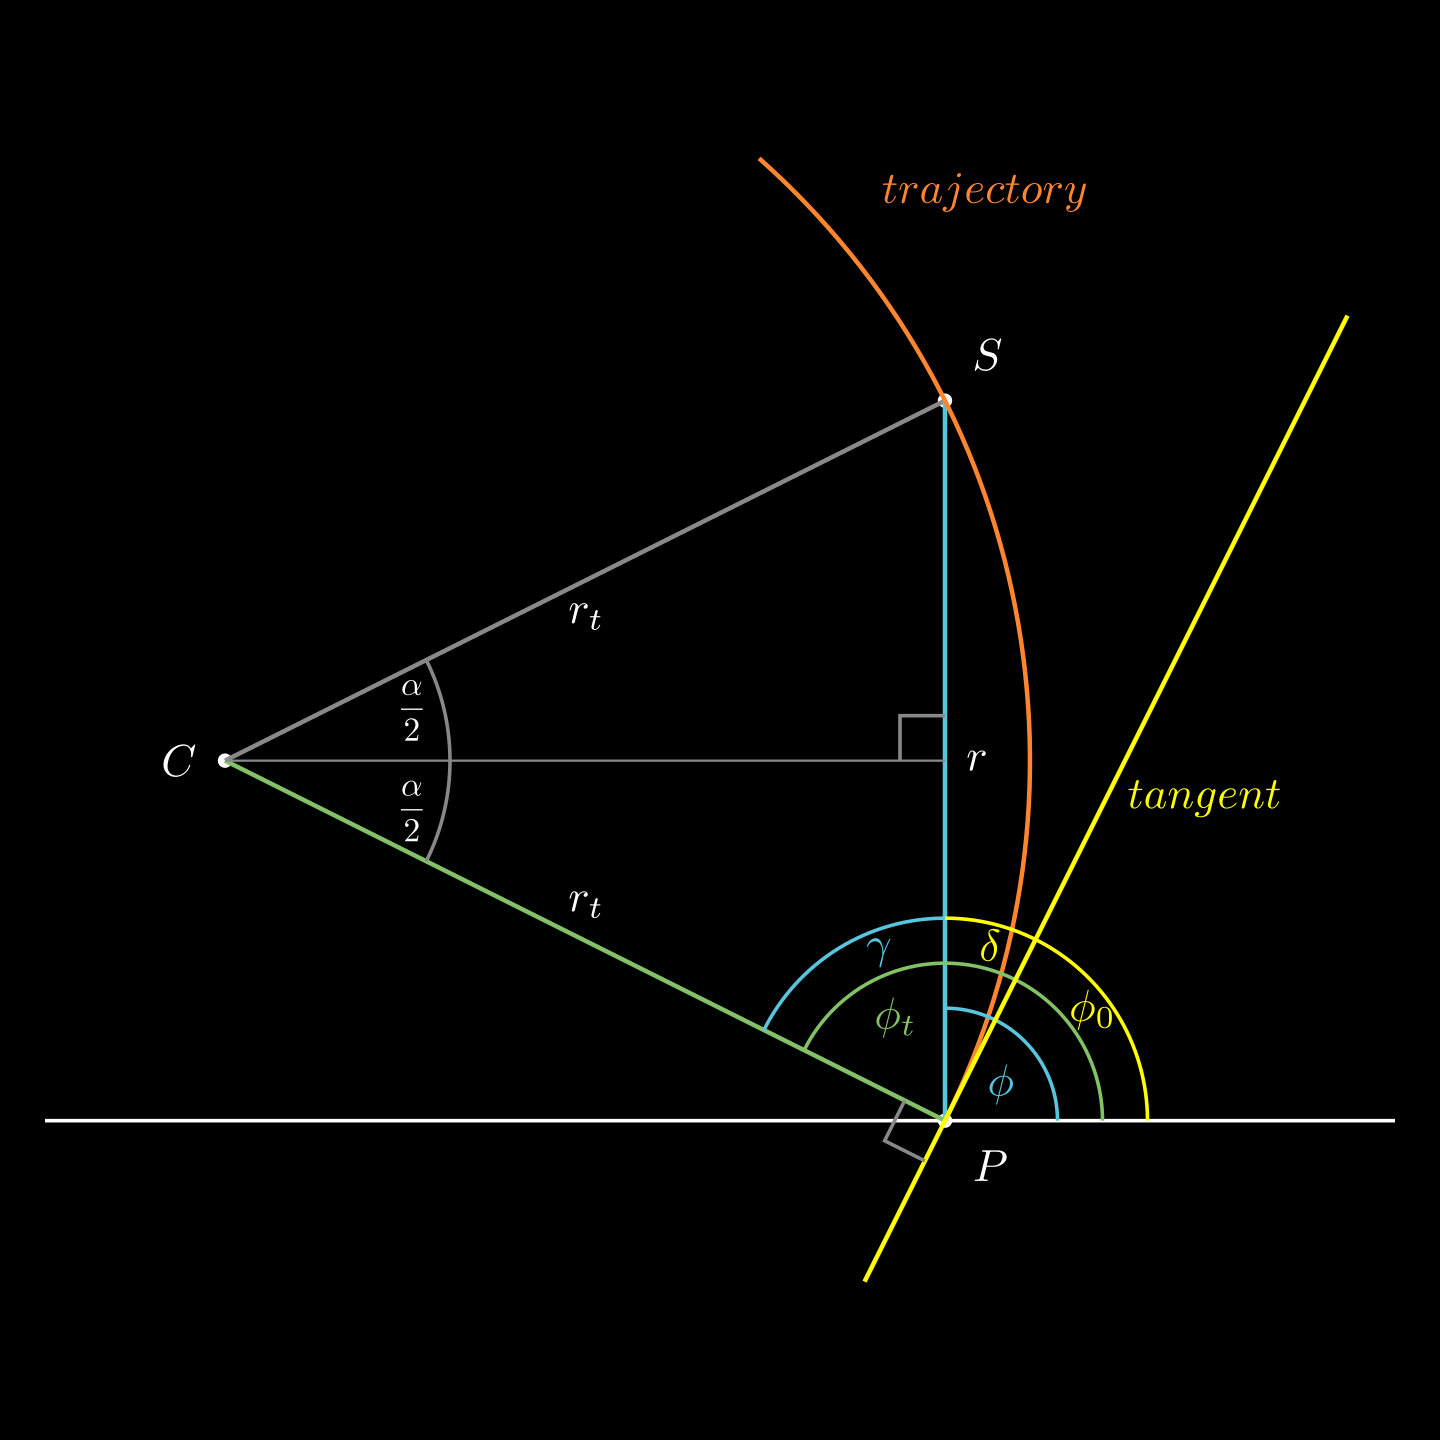

In [15]:
config.frame_width = 16
config.frame_height = 16

class TrajectoryInXYPlaneWithTangent(Scene):
    def construct(self):
        scene_group = VGroup()
        
        # X-axis
        x_axis = Line(start=LEFT * 10, end=RIGHT * 5, color=WHITE)
        scene_group.add(x_axis)

        # Points
        p_coords = np.array([0, 0, 0])
        s_coords = np.array([0, 8, 0])
        c_coords = np.array([-8, 4, 0])

        p = Dot(p_coords, color=WHITE)
        p_label = MathTex("P").next_to(p, DR)
        scene_group.add(p, p_label)

        c = Dot(c_coords, color=WHITE)
        c_label = MathTex("C").next_to(c, LEFT)
        scene_group.add(c, c_label)

        s = Dot(s_coords, color=WHITE)
        s_label = MathTex("S").next_to(s, UR)
        scene_group.add(s, s_label)

        # Lines: CS, CP, SP
        cp = Line(p_coords, c_coords, color=GREEN, stroke_width=5)
        r_t_label = MathTex(r"r_t").next_to(cp.get_midpoint(), UP, buff=0.25)

        cs = Line(c_coords, s_coords, color=GRAY, stroke_width=5)
        r_t_label_2 = MathTex(r"r_t").next_to(cs.get_midpoint(), DOWN, buff=0.25)

        sp = Line(s_coords, p_coords, color=BLUE, stroke_width=5)
        r_label = MathTex(r"r").next_to(sp.get_midpoint(), RIGHT, buff=0.25)

        scene_group.add(cs, cp, sp, r_t_label, r_t_label_2, r_label)

        # Arc from P to some point
        r_t = np.linalg.norm(c_coords - ORIGIN)
        angle_start = np.arctan2(p_coords[1] - c_coords[1], p_coords[0] - c_coords[0])
        arc_angle = 75 * DEGREES
        arc = Arc(
            radius=r_t,
            arc_center=c_coords,
            start_angle=angle_start,
            angle=arc_angle,
            color=ORANGE,
            stroke_width=5
        )
        trajectory_label = MathTex("trajectory").next_to(arc.get_center() + np.array([1, 4.5, 0]), UP)
        trajectory_label.set_color(ORANGE)
        scene_group.add(arc, trajectory_label)

        # Angle phi_t at P for CP direction
        phi_t_angle = Angle(x_axis, cp, radius=1.75, color=GREEN)
        phi_t_label = MathTex(r"\phi_t").next_to(phi_t_angle.get_center() + np.array([-0.2, -0.2, 0]), UL)
        phi_t_label.set_color(GREEN)
        scene_group.add(phi_t_angle, phi_t_label)

        # Angle phi (perhaps phi_s at P for PS)
        ps = Line(ORIGIN, s_coords, color=GRAY)
        phi_angle = Angle(x_axis, ps, radius=1.25, color=BLUE)
        phi_label = MathTex(r"\phi").next_to(phi_angle.get_center(), DOWN, buff=0)
        phi_label.set_color(BLUE)
        scene_group.add(phi_angle, phi_label)

        # Altitude at C
        c_alt = Line(c_coords, (p_coords + s_coords) / 2, color=GRAY, stroke_width=2.5)
        scene_group.add(c_alt)

        alpha_2_angle = Angle(cp, c_alt, radius=2.5, color=GRAY, quadrant=(-1, 1))
        alpha_2_label = MathTex(r"\frac{\alpha}{2}").next_to(alpha_2_angle, LEFT, buff=0).scale(0.75)
        scene_group.add(alpha_2_angle, alpha_2_label)

        alpha_2_angle_2 = Angle(c_alt, cs, radius=2.5, color=GRAY, quadrant=(1, 1))
        alpha_2_label_2 = MathTex(r"\frac{\alpha}{2}").next_to(alpha_2_angle_2, LEFT, buff=0).scale(0.75)
        scene_group.add(alpha_2_angle_2, alpha_2_label_2)

        # right angle at c alt and ps
        right_angle = RightAngle(c_alt, ps, length=0.5, quadrant=(-1, 1), color=GRAY)
        scene_group.add(right_angle)

        # line perpendicular to CP at P
        tangent_dir = np.array([c_coords[1], -c_coords[0], 0]) / np.linalg.norm(np.array([c_coords[1], -c_coords[0], 0]))
        tangent_line = Line(p_coords - tangent_dir * 2, p_coords + tangent_dir * 10, color=YELLOW, stroke_width=5)
        tangent_line_label = MathTex(r"tangent").next_to(tangent_line.get_midpoint(), RIGHT, buff=0.25)
        tangent_line_label.set_color(YELLOW)
        scene_group.add(tangent_line, tangent_line_label)

        # angle between tangent line and x axis
        tangent_angle = Angle(x_axis, tangent_line, radius=2.25, color=YELLOW)
        tangent_angle_label = MathTex(r"\phi_{0}").next_to(tangent_angle.get_center(), UP, buff=0)
        tangent_angle_label.set_color(YELLOW)
        scene_group.add(tangent_angle, tangent_angle_label)

        # angle between tangent line SP
        sp_angle = Angle(tangent_line, sp, radius=2.25, quadrant=(1, -1), color=YELLOW)
        sp_angle_label = MathTex(r"\delta").next_to(sp_angle.get_center(), DOWN, buff=0)
        sp_angle_label.set_color(YELLOW)
        scene_group.add(sp_angle, sp_angle_label)

        # angle between tangent SP and CP
        sp_cp_angle = Angle(sp, cp, radius=2.25, quadrant=(-1, 1), color=BLUE)
        sp_cp_angle_label = MathTex(r"\gamma").next_to(sp_cp_angle.get_center(), DL, buff=-0.4)
        sp_cp_angle_label.set_color(BLUE)
        scene_group.add(sp_cp_angle, sp_cp_angle_label)

        # angle between tangent line and CP
        tangent_cp_angle = RightAngle(tangent_line, cp, length=0.5, quadrant=(-1, 1), color=GRAY)
        scene_group.add(tangent_cp_angle)

        scene_group.center()
        self.add(scene_group)

%manim -qh -r 1440,1440 -v WARNING TrajectoryInXYPlaneWithTangent

Manim Community v0.19.0

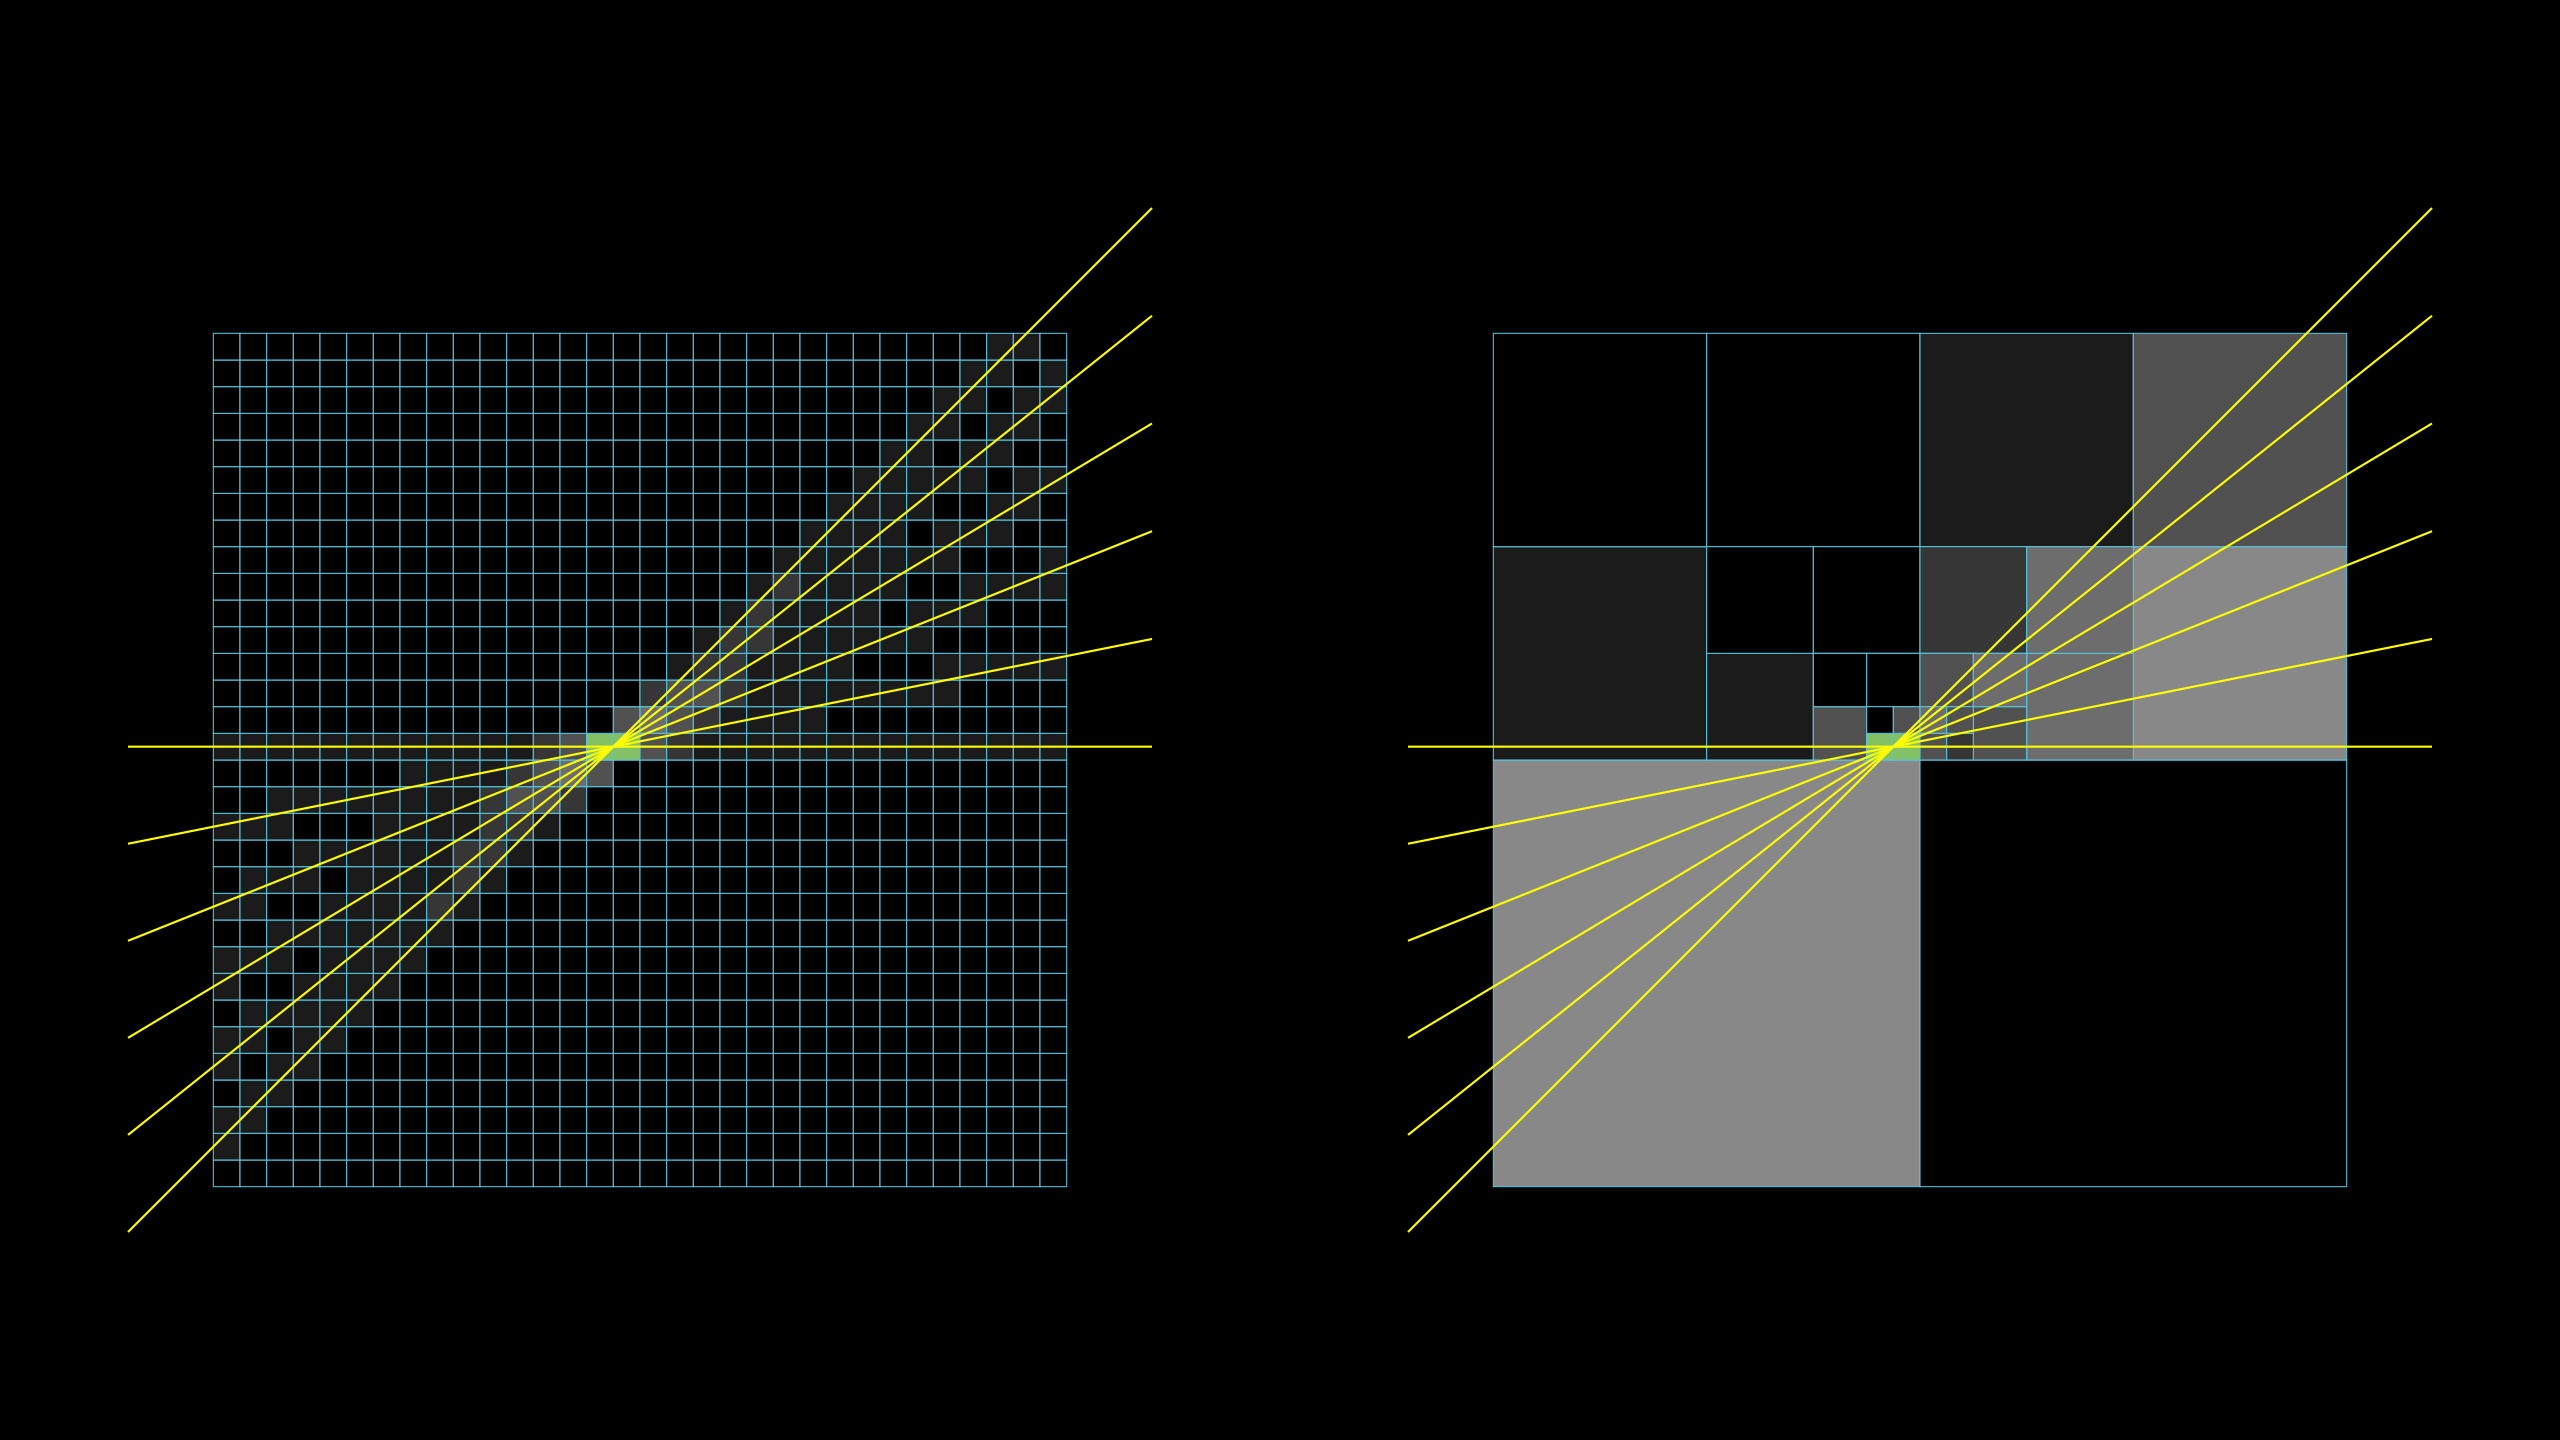

In [16]:
config.frame_width = 96
config.frame_height = 54

class Cell:
    def __init__(self, x_min, x_max, y_min, y_max, state=None):
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max
        self.state = state

    def get_hits(self, points, func):
        hits = []
        for point in points:
            y_left = func(point, self.x_min)
            y_right = func(point, self.x_max)

            hit = False
            hit = hit or (y_left >= self.y_min and y_left <= self.y_max)
            hit = hit or (y_right >= self.y_min and y_right <= self.y_max)
            hit = hit or (y_left <= self.y_min and y_right >= self.y_min)
            hit = hit or (y_left >= self.y_max and y_right <= self.y_max)
            if hit:
                hits.append(point)

        self.num_hits = len(hits)
        return hits

    def get_children(self):
        return [
            Cell(self.x_min, (self.x_min + self.x_max) / 2, self.y_min, (self.y_min + self.y_max) / 2),
            Cell((self.x_min + self.x_max) / 2, self.x_max, self.y_min, (self.y_min + self.y_max) / 2),
            Cell(self.x_min, (self.x_min + self.x_max) / 2, (self.y_min + self.y_max) / 2, self.y_max),
            Cell((self.x_min + self.x_max) / 2, self.x_max, (self.y_min + self.y_max) / 2, self.y_max),
        ]

    def __str__(self):
        return f"Cell(x_min={self.x_min}, x_max={self.x_max}, y_min={self.y_min}, y_max={self.y_max}, state={self.state}, num_hits={self.num_hits})"

def hough_transform_function(point, x):
    return point[0] * x + point[1]

slope_multiplier = 0.2
intercept_multiplier = 3
points = [
    (0 * slope_multiplier, 5 * intercept_multiplier + 1.5),
    (1 * slope_multiplier, 4 * intercept_multiplier + 1.5),
    (2 * slope_multiplier, 3 * intercept_multiplier + 1.5),
    (3 * slope_multiplier, 2 * intercept_multiplier + 1.5),
    (4 * slope_multiplier, 1 * intercept_multiplier + 1.5),
    (5 * slope_multiplier, 0 * intercept_multiplier + 1.5)
]

accumulator_min_x = 0
accumulator_max_x = 32
accumulator_min_y = 0
accumulator_max_y = 32
accumulator_width = accumulator_max_x - accumulator_min_x
accumulator_height = accumulator_max_y - accumulator_min_y
hits_threshold = 5

traditional_accumulator = []
for x in range(accumulator_min_x, accumulator_max_x):
    for y in range(accumulator_min_y, accumulator_max_y):
        cell = Cell(x, x + 1, y, y + 1)
        hits = cell.get_hits(points, hough_transform_function)
        state = "solution" if len(hits) > hits_threshold else "discarded"
        cell.state = state
        traditional_accumulator.append(cell)

adaptive_accumulator = []
accumulator_stack = []
accumulator_stack.append(Cell(accumulator_min_x, accumulator_max_x, accumulator_min_y, accumulator_max_y))
while len(accumulator_stack) > 0:
    cell = accumulator_stack.pop(0)
    hits = cell.get_hits(points, hough_transform_function)

    if cell.x_max - cell.x_min > 1:
        state = "divided" if len(hits) > hits_threshold else "discarded"
    else:
        state = "solution" if len(hits) > hits_threshold else "discarded"

    if state == "discarded" or state == "solution":
        cell.state = state
        adaptive_accumulator.append(cell)
    else:
        accumulator_stack.extend(cell.get_children())

class TraditionalVsAdaptiveAccumulator(Scene):
    def construct(self):
        def create_cell_drawing(cell):
            rect = Rectangle(
                width=cell.x_max - cell.x_min,
                height=cell.y_max - cell.y_min,
                fill_color=GREEN if cell.state == "solution" else GRAY * min(cell.num_hits / hits_threshold, 1),
                fill_opacity=1,
                stroke_color=BLUE,
                stroke_width=4
            )
            rect.move_to(np.array([(cell.x_min + cell.x_max) / 2, (cell.y_min + cell.y_max) / 2, 0]))
            return rect
        
        # Traditional accumulator cells
        traditional_accumulator_group = VGroup()
        for cell in traditional_accumulator:
            traditional_accumulator_group.add(create_cell_drawing(cell))

        # Adaptive accumulator cells
        adaptive_accumulator_group = VGroup()
        for cell in adaptive_accumulator:
            adaptive_accumulator_group.add(create_cell_drawing(cell))

        # Points
        def draw_points(points, group):
            for point in points:
                start_x = accumulator_min_x - accumulator_width * 0.1
                end_x = accumulator_max_x + accumulator_width * 0.1
                start = np.array([start_x, hough_transform_function(point, start_x), 0])
                end = np.array([end_x, hough_transform_function(point, end_x), 0])
                line = Line(start, end, color=YELLOW, stroke_width=8)
                group.add(line)

        draw_points(points, traditional_accumulator_group)
        draw_points(points, adaptive_accumulator_group)

        scene_group = VGroup()
        traditional_accumulator_group.shift(np.array([-24, 0, 0]))
        adaptive_accumulator_group.shift(np.array([24, 0, 0]))
        scene_group.add(traditional_accumulator_group, adaptive_accumulator_group)

        scene_group.center()
        self.add(scene_group)

%manim -qh -r 2560,1440 -v WARNING TraditionalVsAdaptiveAccumulator

Manim Community v0.19.0

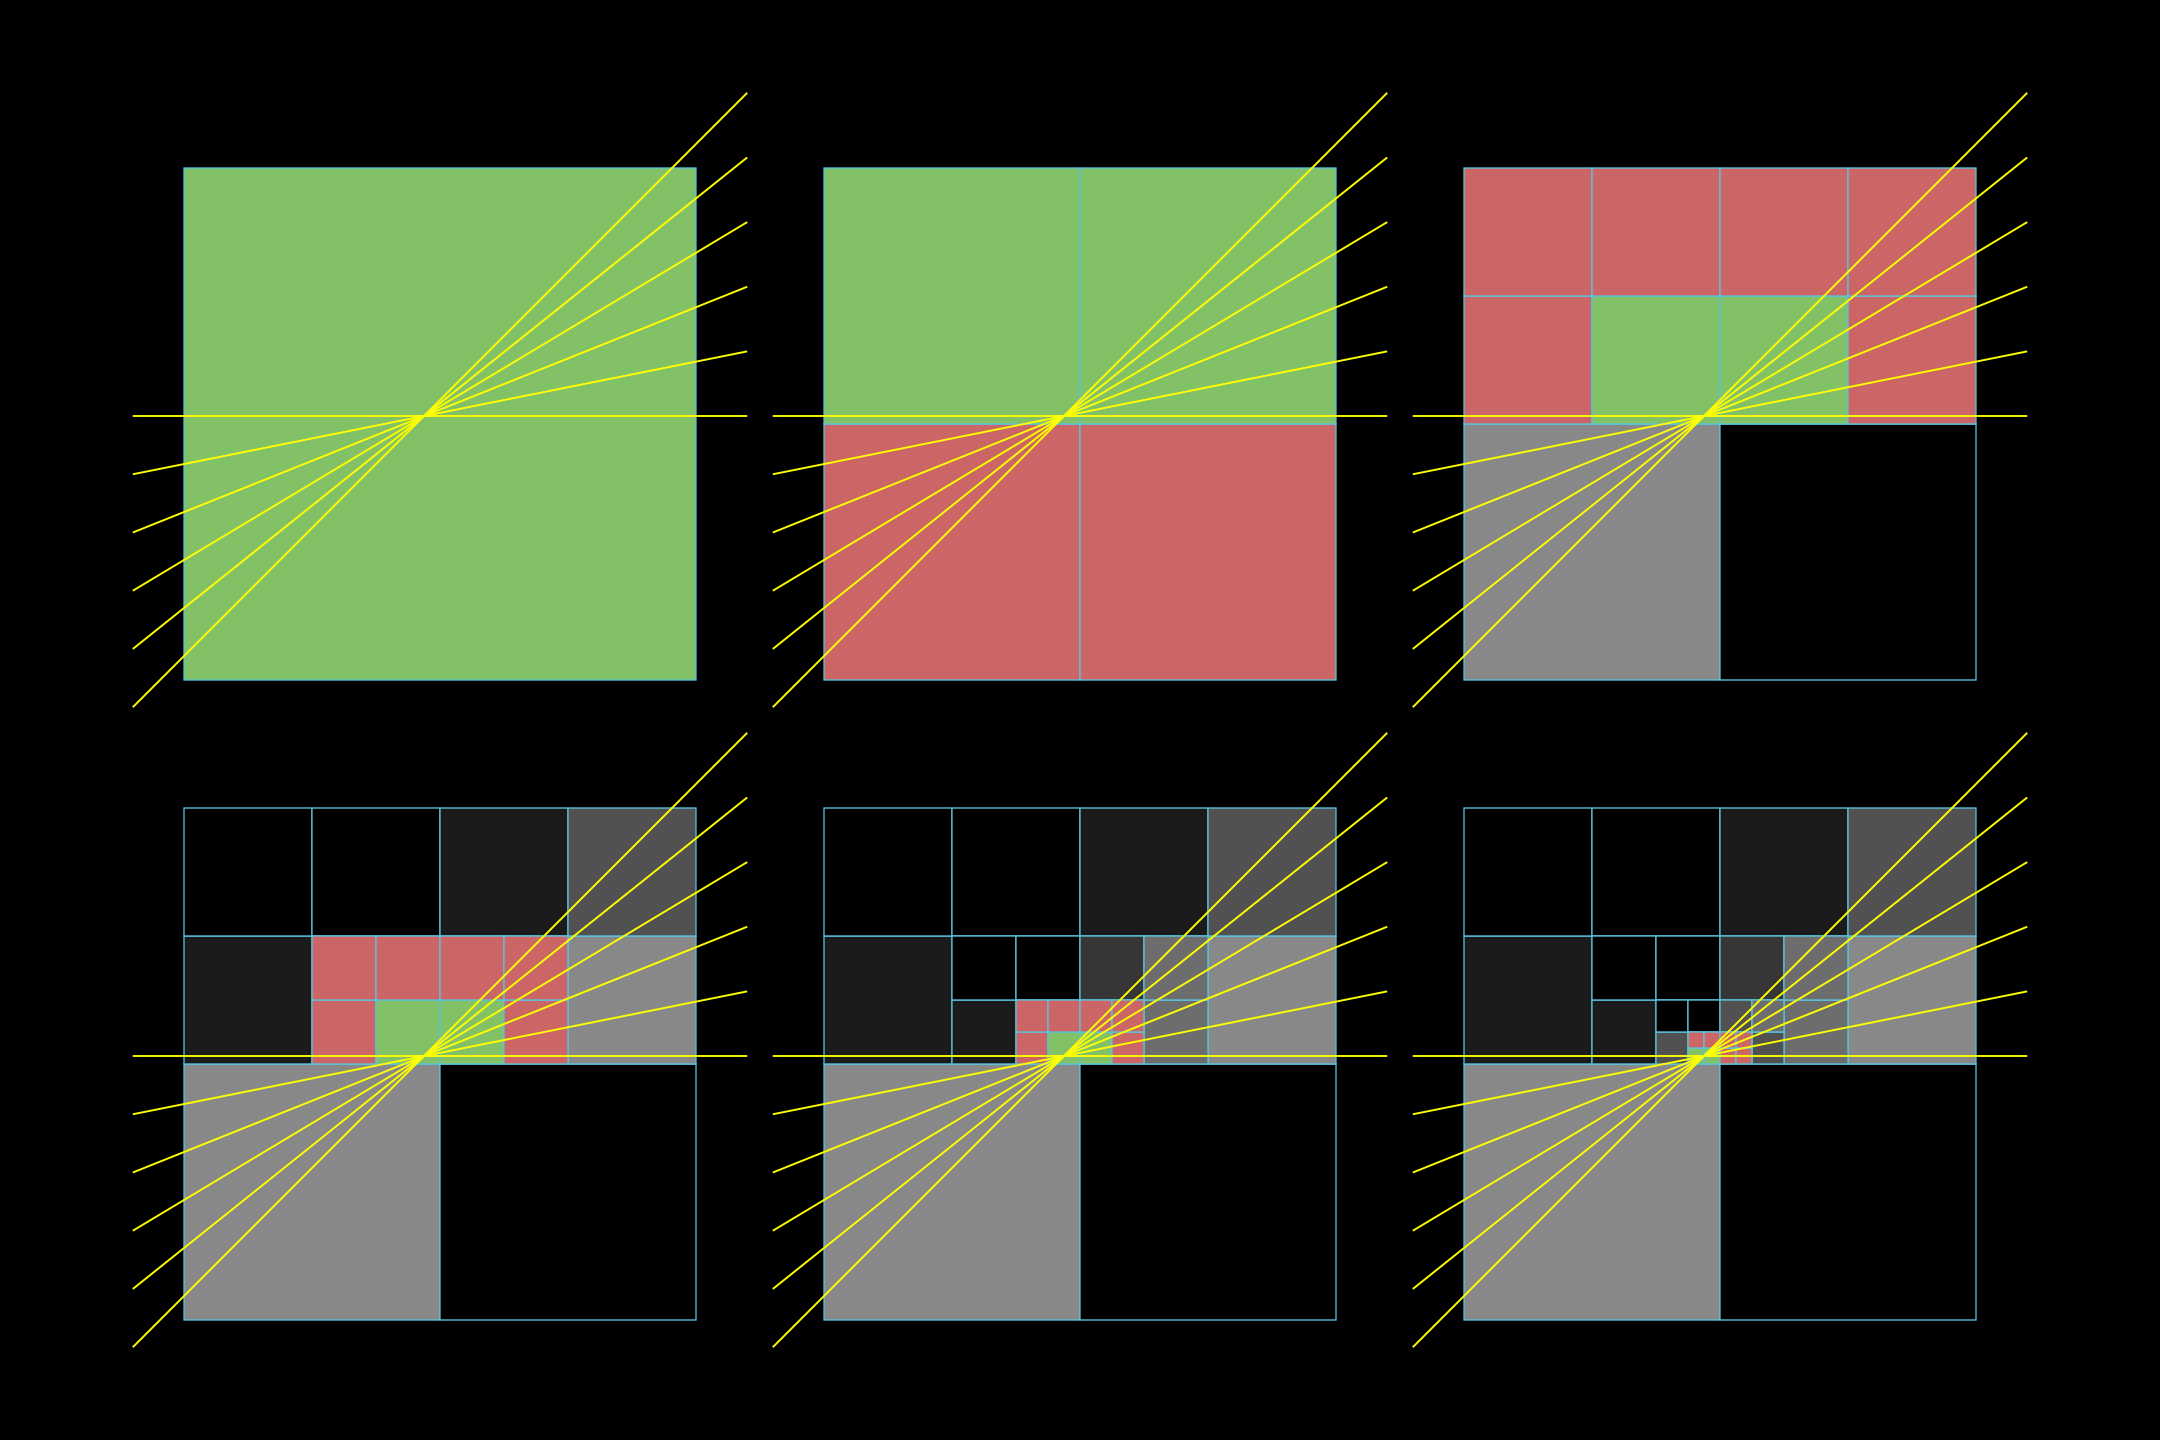

In [17]:
config.frame_width = 135
config.frame_height = 90

def create_accumulator_image(target_division_level):
    adaptive_accumulator = []
    accumulator_stack = []
    accumulator_stack.append(Cell(accumulator_min_x, accumulator_max_x, accumulator_min_y, accumulator_max_y))
    while len(accumulator_stack) > 0:
        cell = accumulator_stack.pop(0)
        hits = cell.get_hits(points, hough_transform_function)

        if cell.x_max - cell.x_min > accumulator_width / 2 ** target_division_level:
            state = "divided" if len(hits) > hits_threshold else "discarded"
        else:
            state = "solution" if len(hits) > hits_threshold else "discarded_fresh"

        if state == "discarded" or state == "discarded_fresh" or state == "solution":
            cell.state = state
            adaptive_accumulator.append(cell)
        else:
            accumulator_stack.extend(cell.get_children())
    return adaptive_accumulator

class TraditionalVsAdaptiveAccumulator(Scene):
    def construct(self):
        def create_cell_drawing(cell):
            if cell.state == "divided" or cell.state == "solution":
                fill_color = GREEN
            elif cell.state == "discarded_fresh":
                fill_color = np.array([0.8, 0.4, 0.4])
            else:
                fill_color = GRAY * min(cell.num_hits / hits_threshold, 1)
            
            rect = Rectangle(
                width=cell.x_max - cell.x_min,
                height=cell.y_max - cell.y_min,
                fill_color=fill_color,
                fill_opacity=1,
                stroke_color=BLUE,
                stroke_width=8
            )
            rect.move_to(np.array([(cell.x_min + cell.x_max) / 2, (cell.y_min + cell.y_max) / 2, 0]))
            return rect
        
        accumulator_groups = []
        for division_level in range(6):
            accumulator_max_x = 2 ** division_level
            accumulator_max_y = 2 ** division_level
            accumulator_width = accumulator_max_x - accumulator_min_x
            accumulator_height = accumulator_max_y - accumulator_min_y

            accumulator_image = create_accumulator_image(division_level)

            accumulator_group = VGroup()
            for cell in accumulator_image:
                accumulator_group.add(create_cell_drawing(cell))
            accumulator_groups.append(accumulator_group)

        # Points
        def draw_points(points, group):
            for point in points:
                start_x = accumulator_min_x - accumulator_width * 0.1
                end_x = accumulator_max_x + accumulator_width * 0.1
                start = np.array([start_x, hough_transform_function(point, start_x), 0])
                end = np.array([end_x, hough_transform_function(point, end_x), 0])
                line = Line(start, end, color=YELLOW, stroke_width=12)
                group.add(line)
        
        for accumulator_group in accumulator_groups:
            draw_points(points, accumulator_group)

        group_shifts = []
        group_shifts.append(np.array([-40, 20, 0]))
        group_shifts.append(np.array([0, 20, 0]))
        group_shifts.append(np.array([40, 20, 0]))
        group_shifts.append(np.array([-40, -20, 0]))
        group_shifts.append(np.array([0, -20, 0]))
        group_shifts.append(np.array([40, -20, 0]))

        scene_group = VGroup()
        for i, accumulator_group in enumerate(accumulator_groups):
            accumulator_group.shift(group_shifts[i])
            scene_group.add(accumulator_group)

        scene_group.center()
        self.add(scene_group)

%manim -qh -r 2160,1440 -v WARNING TraditionalVsAdaptiveAccumulator

Manim Community v0.19.0

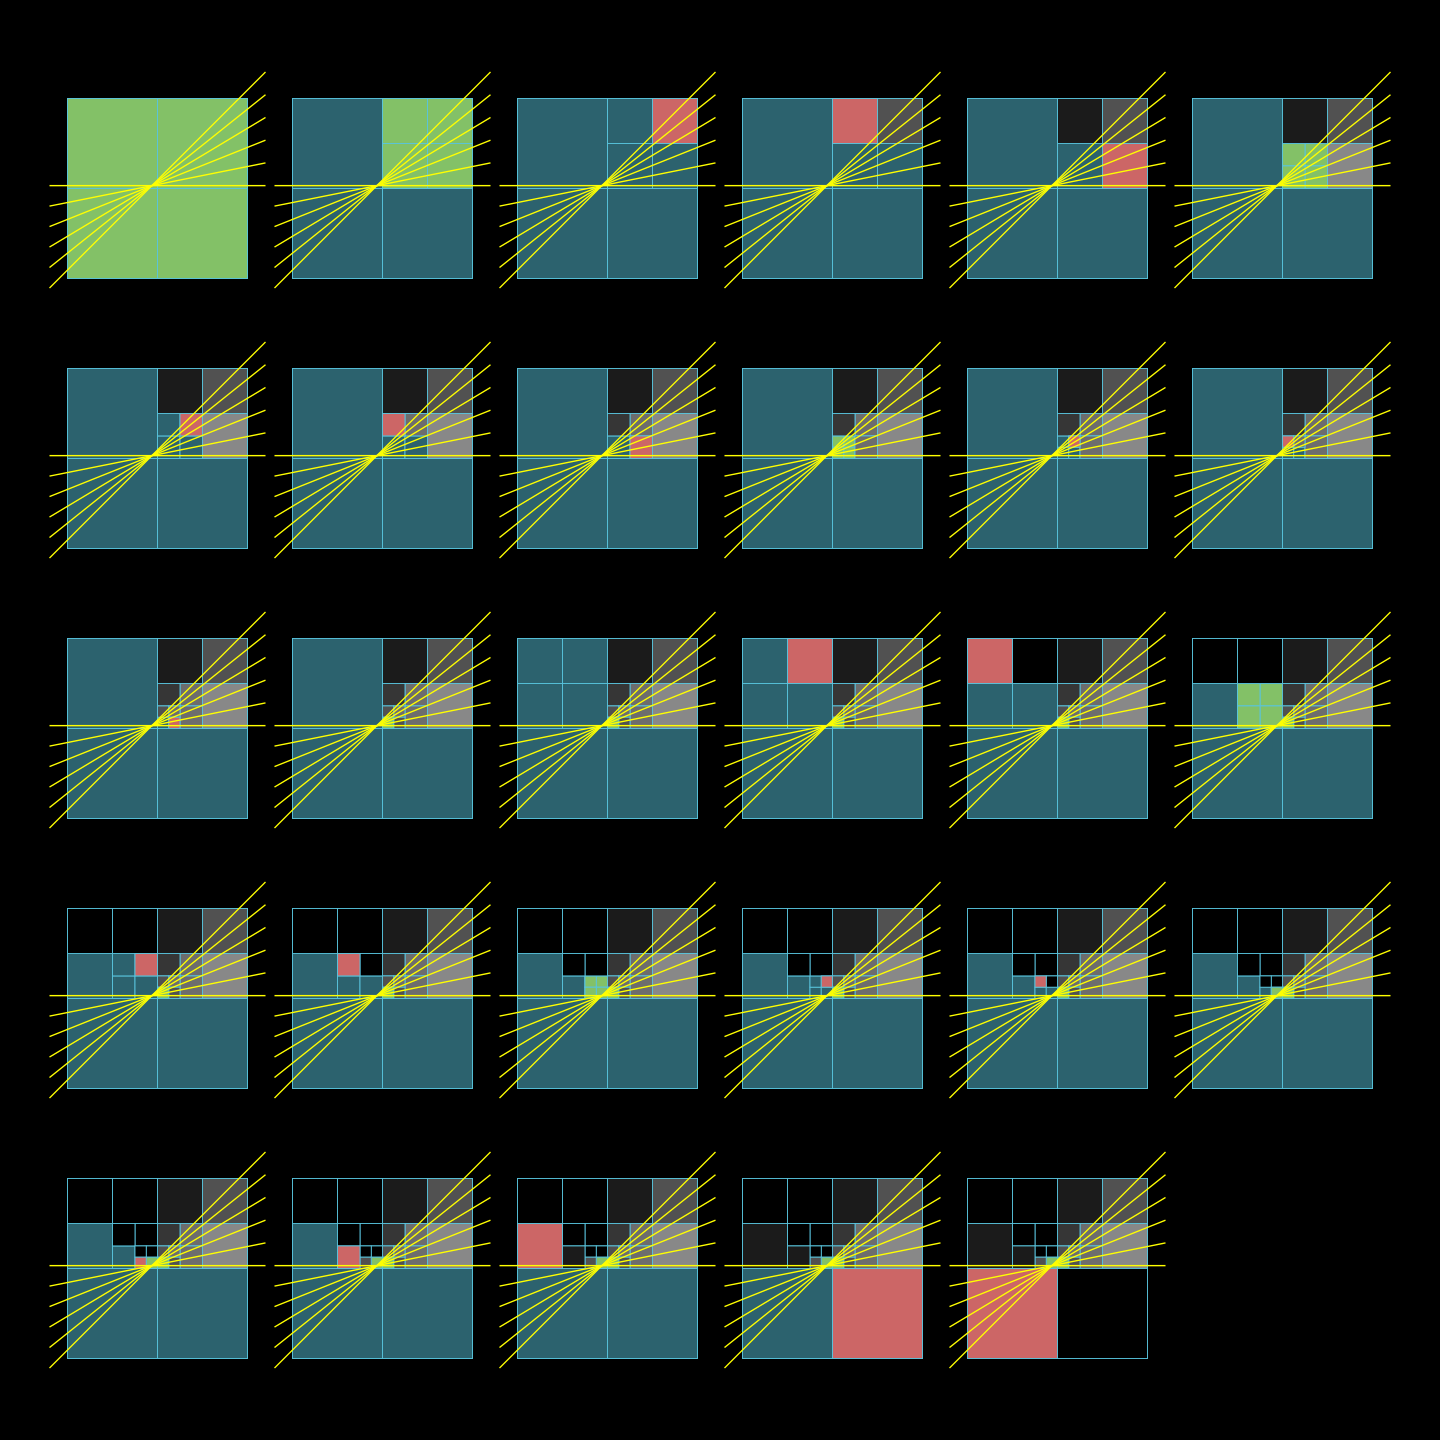

In [18]:
config.frame_width = 128
config.frame_height = 120

division_level = 4
accumulator_max_x = 2 ** division_level
accumulator_max_y = 2 ** division_level
accumulator_width = accumulator_max_x - accumulator_min_x
accumulator_height = accumulator_max_y - accumulator_min_y

slope_multiplier = 0.2
intercept_multiplier = 1.5
points = [
    (0 * slope_multiplier, 5 * intercept_multiplier + 0.75),
    (1 * slope_multiplier, 4 * intercept_multiplier + 0.75),
    (2 * slope_multiplier, 3 * intercept_multiplier + 0.75),
    (3 * slope_multiplier, 2 * intercept_multiplier + 0.75),
    (4 * slope_multiplier, 1 * intercept_multiplier + 0.75),
    (5 * slope_multiplier, 0 * intercept_multiplier + 0.75)
]

def create_accumulator_image(target_division_level, max_steps=1):
    adaptive_accumulator = []
    accumulator_stack = []
    processed_cells = []
    accumulator_stack.append(Cell(accumulator_min_x, accumulator_max_x, accumulator_min_y, accumulator_max_y))
    steps = 0
    while len(accumulator_stack) > 0 and steps < max_steps:
        steps += 1
        cell = accumulator_stack[-1]
        accumulator_stack = accumulator_stack[:-1]
        hits = cell.get_hits(points, hough_transform_function)

        if cell.x_max - cell.x_min > accumulator_width / 2 ** target_division_level:
            state = "divided" if len(hits) > hits_threshold else "discarded"
        else:
            state = "solution" if len(hits) > hits_threshold else "discarded"

        cell.state = state
        if state == "discarded" or state == "solution":
            cell.state = "discarded_fresh" if steps == max_steps and state == "discarded" else state
            adaptive_accumulator.append(cell)
        else:
            processed_cells.append(cell)
            accumulator_stack.extend(cell.get_children())
    return adaptive_accumulator, accumulator_stack, processed_cells

class TraditionalVsAdaptiveAccumulator(Scene):
    def construct(self):
        def create_cell_drawing(cell):
            if cell.state is None:
                fill_color = BLUE * 0.5
            elif cell.state == "divided" or cell.state == "solution":
                fill_color = GREEN
            elif cell.state == "discarded_fresh":
                fill_color = np.array([0.8, 0.4, 0.4])
            else:
                fill_color = GRAY * min(cell.num_hits / hits_threshold, 1)
            
            rect = Rectangle(
                width=cell.x_max - cell.x_min,
                height=cell.y_max - cell.y_min,
                fill_color=fill_color,
                fill_opacity= 1 if cell.state != "divided" else 0,
                stroke_color=BLUE,
                stroke_width=8
            )
            rect.move_to(np.array([(cell.x_min + cell.x_max) / 2, (cell.y_min + cell.y_max) / 2, 0]))
            return rect
        
        accumulator_groups = []

        for max_steps in range(1, 30):
            accumulator_image, accumulator_stack, processed_cells = create_accumulator_image(division_level, max_steps)

            accumulator_group = VGroup()
            for cell in processed_cells:
                accumulator_group.add(create_cell_drawing(cell))
            for cell in accumulator_stack:
                accumulator_group.add(create_cell_drawing(cell))
            if processed_cells[-1].state == "divided" and (len(accumulator_image) == 0 or (accumulator_image[-1].state != "discarded_fresh" and accumulator_image[-1].state != "solution")):
                
                accumulator_stack[-1].state = "solution"
                accumulator_stack[-2].state = "solution"
                accumulator_stack[-3].state = "solution"
                accumulator_stack[-4].state = "solution"
                accumulator_group.add(create_cell_drawing(accumulator_stack[-1]))
                accumulator_group.add(create_cell_drawing(accumulator_stack[-2]))
                accumulator_group.add(create_cell_drawing(accumulator_stack[-3]))
                accumulator_group.add(create_cell_drawing(accumulator_stack[-4]))
            for cell in accumulator_image:
                accumulator_group.add(create_cell_drawing(cell))

            accumulator_groups.append(accumulator_group)

        # Points
        def draw_points(points, group):
            for point in points:
                start_x = accumulator_min_x - accumulator_width * 0.1
                end_x = accumulator_max_x + accumulator_width * 0.1
                start = np.array([start_x, hough_transform_function(point, start_x), 0])
                end = np.array([end_x, hough_transform_function(point, end_x), 0])
                line = Line(start, end, color=YELLOW, stroke_width=12)
                group.add(line)
        
        for accumulator_group in accumulator_groups:
            draw_points(points, accumulator_group)

        group_shifts = []
        for y in range(5):
            for x in range(6):
                group_shifts.append(np.array([20 * x, -24 * y, 0]))

        scene_group = VGroup()
        for i, accumulator_group in enumerate(accumulator_groups):
            accumulator_group.shift(group_shifts[i % len(group_shifts)])
            scene_group.add(accumulator_group)

        scene_group.center()
        self.add(scene_group)

%manim -qh -r 1440,1440 -v WARNING TraditionalVsAdaptiveAccumulator

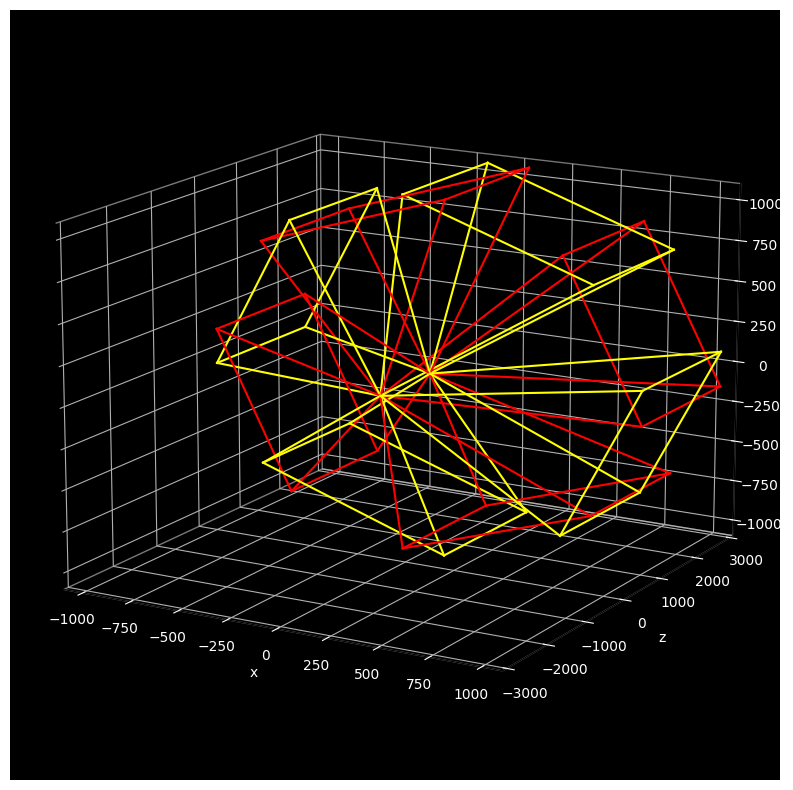

In [19]:
max_abs_z = 3100
max_abs_xy = 1100

z_ranges = [(angle_wrap_2pi(i[0]), angle_wrap_2pi(i[1])) for i in uniform_range_split(8, 0, 2 * math.pi, math.pi / 32)]
wedges = [Wedge(z_range[0], z_range[1], 1 * 1 / 8 * math.pi, 3 * 1 / 8 * math.pi, 2 * 0.2 * max_abs_z) for z_range in z_ranges]

perspective = {'elev': 15, 'azim': -60, 'roll': 0}
detector_plot = DetectorPlot(perspective=perspective)
for i, wedge in enumerate(wedges):
    detector_plot.plot_wedge(wedge, color="red" if i % 2 == 0 else "yellow")




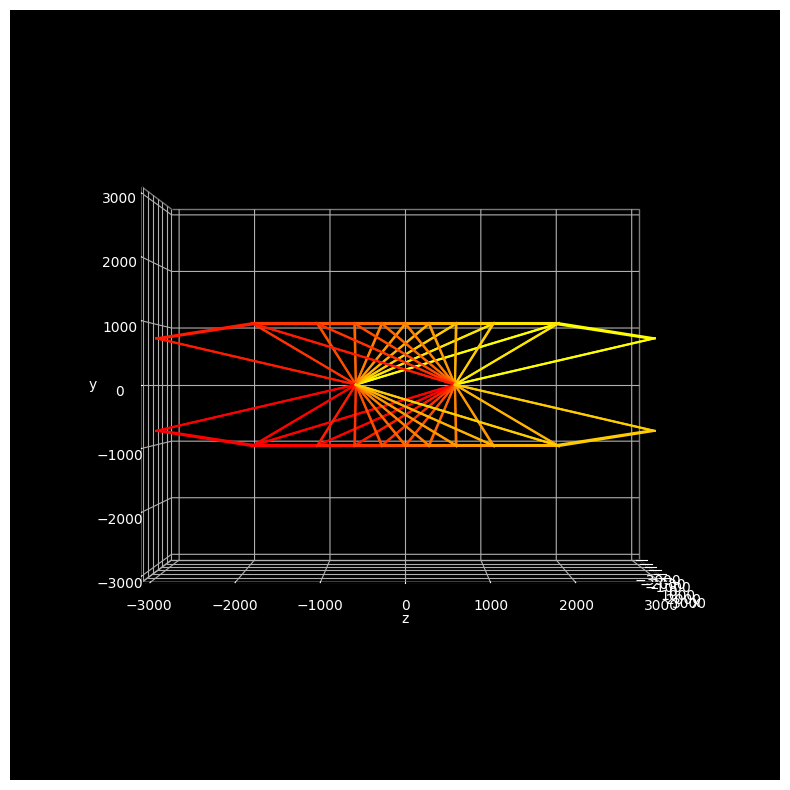

In [20]:
num_wedges = 24
wedges = [Wedge(3 * 1 / 8 * math.pi, 5 * 1 / 8 * math.pi, i * 1 / (num_wedges / 2) * math.pi, (i + 1) * 1 / (num_wedges / 2) * math.pi, 2 * 0.2 * max_abs_z) for i in range(num_wedges)]

# remove indexes 0, 7, 8, 15
wedges = [wedge for i, wedge in enumerate(wedges) if i not in [0, 11, 12, 23]]

perspective = {'elev': 0, 'azim': 0, 'roll': 0}
detector_plot = DetectorPlot(perspective=perspective, keep_aspect_ratio=True)
colors = []
colors.append((1, 1, 0))
colors.append((1, 0.9, 0))
colors.append((1, 0.8, 0))
colors.append((1, 0.7, 0))
colors.append((1, 0.6, 0))
colors.append((1, 0.5, 0))
colors.append((1, 0.4, 0))
colors.append((1, 0.3, 0))
colors.append((1, 0.2, 0))
colors.append((1, 0.1, 0))
colors.append((1, 0, 0))
colors.extend(reversed(colors))

for i, wedge in enumerate(wedges):
    detector_plot.plot_wedge(wedge, color=colors[i % len(colors)])

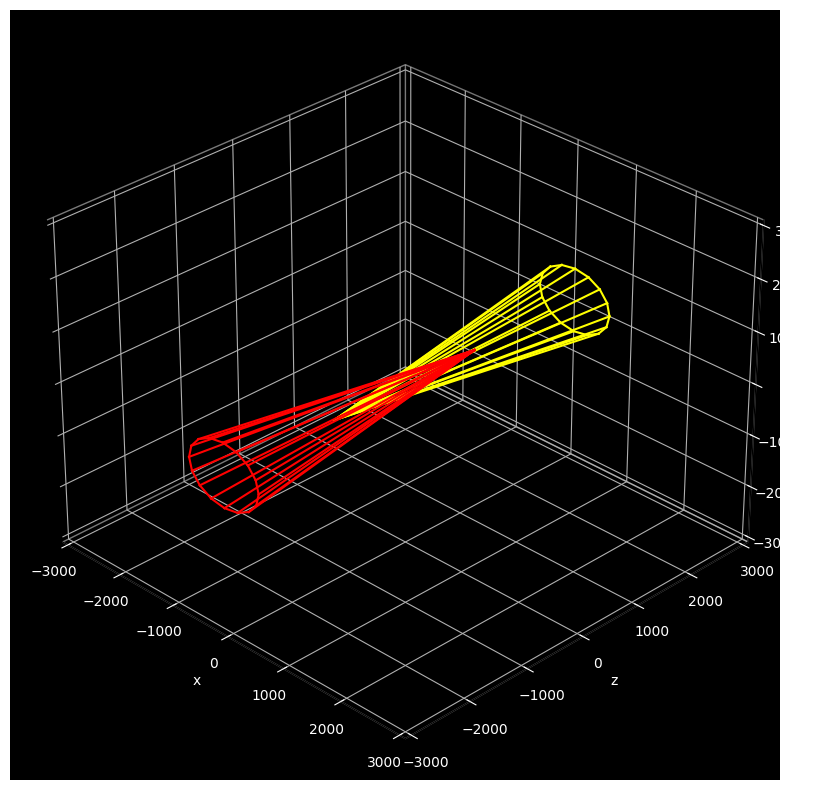

In [21]:
pole_region = PoleRegion(4 / 64 * math.pi, 4 * 0.2 * max_abs_z)
pole_region2 = PoleRegion(60 / 64 * math.pi, 4 * 0.2 * max_abs_z)

perspective = {'elev': 30, 'azim': -45, 'roll': 0}
detector_plot = DetectorPlot(perspective=perspective, keep_aspect_ratio=True)
num_rays = 16
detector_plot.plot_pole_region(pole_region, num_rays=num_rays, color="yellow")
detector_plot.plot_pole_region(pole_region2, num_rays=num_rays, color="red")

Manim Community v0.19.0

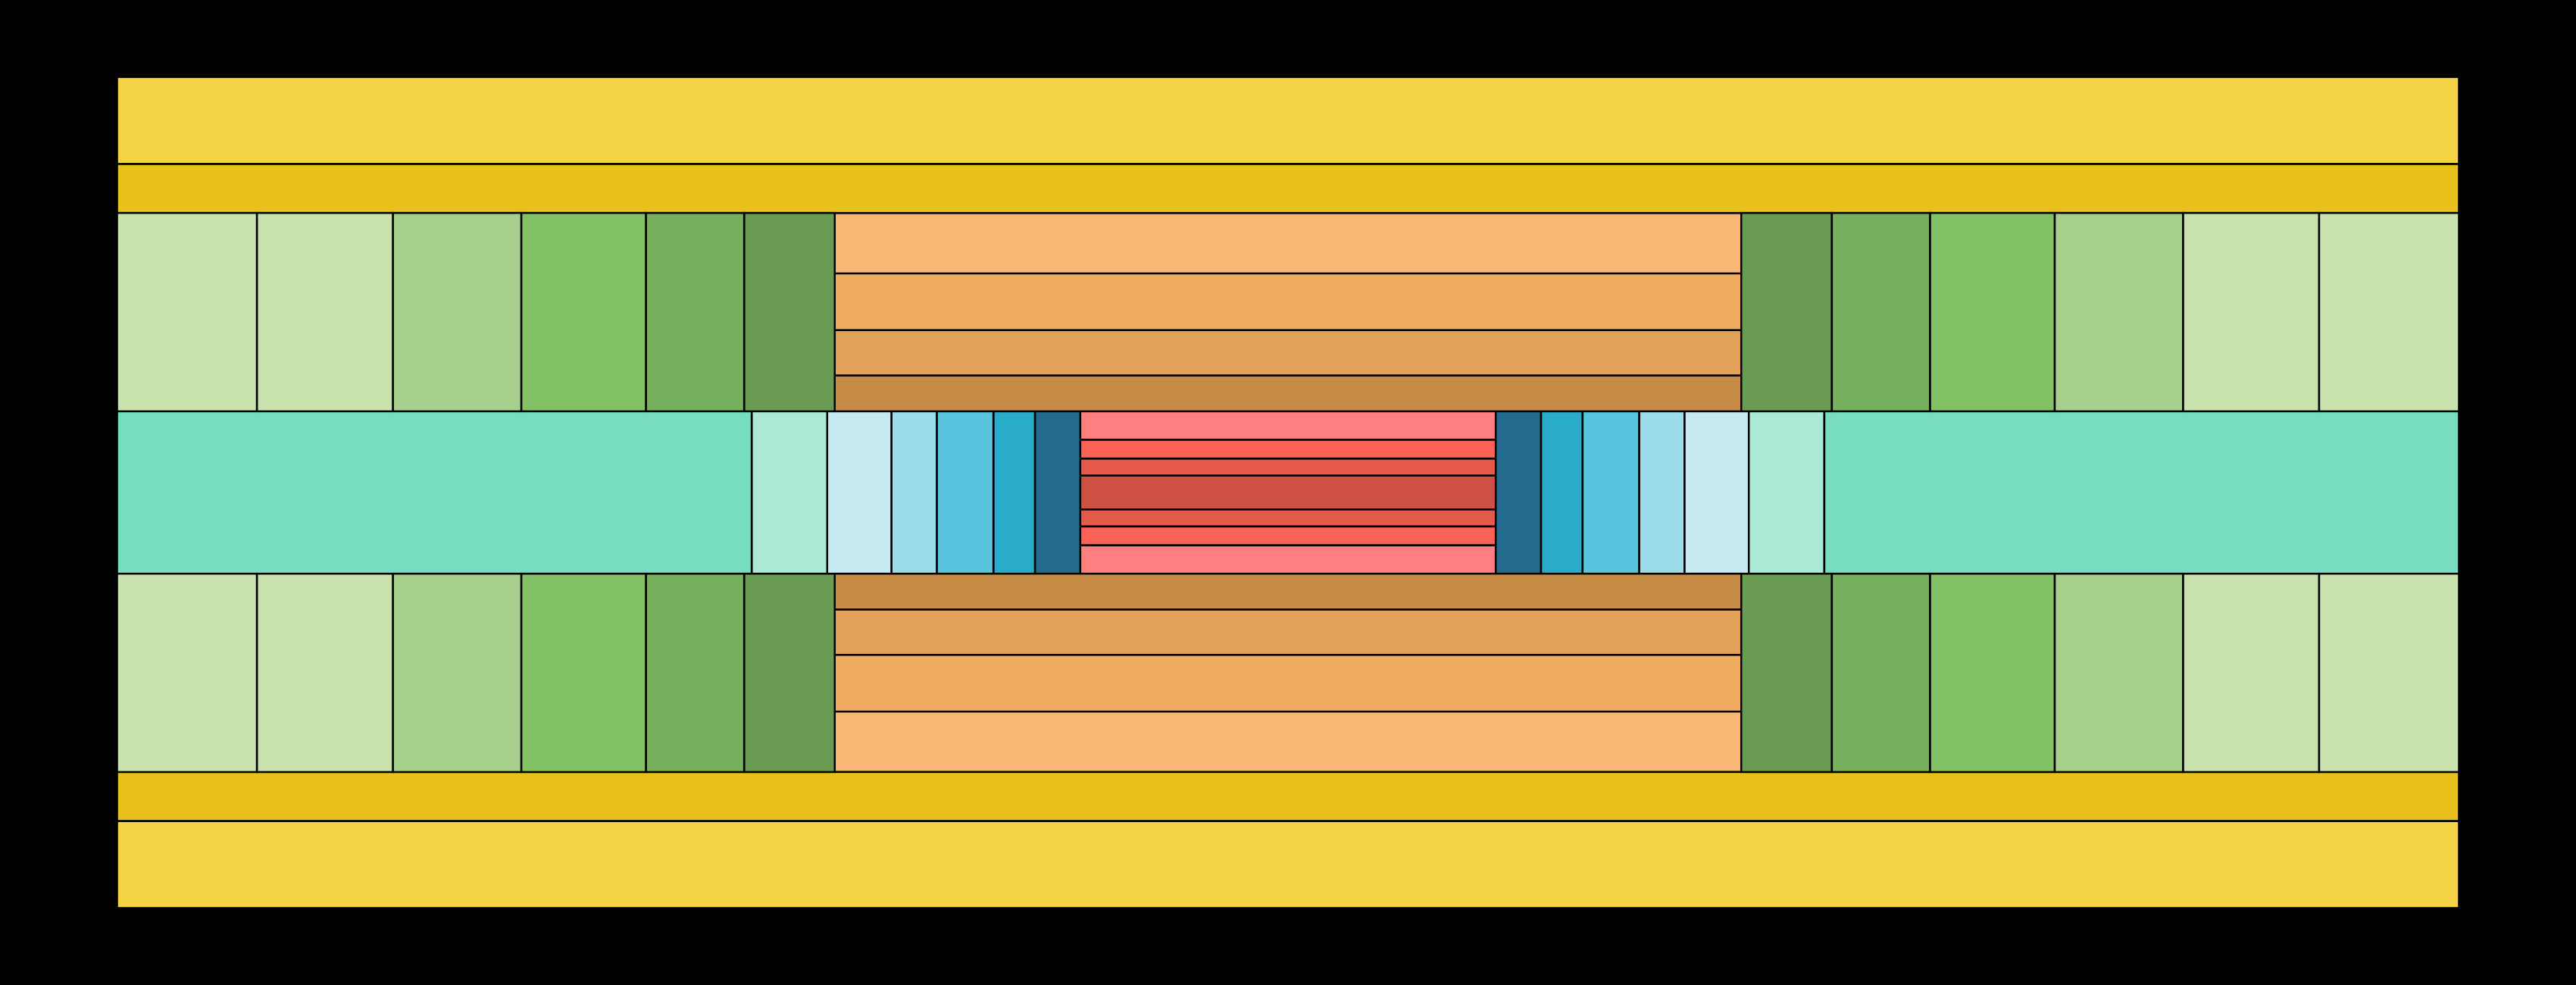

In [53]:
class Layer:
    def __init__(self, r_min, r_max, z_min, z_max, color):
        self.r_min = r_min
        self.r_max = r_max
        self.z_min = z_min
        self.z_max = z_max
        self.color = color

    def __str__(self):
        return f"Layer(r_min={self.r_min}, r_max={self.r_max}, z_min={self.z_min}, z_max={self.z_max}, color={self.color})"

    def get_rectangles(self):
        if self.r_min == 0 and self.z_min == 0:
            return [
                {"r_min": -self.r_max, "r_max": self.r_max, "z_min": -self.z_max, "z_max": self.z_max, "color": self.color}
            ]
        elif self.r_min != 0 and self.z_min == 0:
            return [
                {"r_min": self.r_min, "r_max": self.r_max, "z_min": -self.z_max, "z_max": self.z_max, "color": self.color},
                {"r_min": -self.r_max, "r_max": -self.r_min, "z_min": -self.z_max, "z_max": self.z_max, "color": self.color}
            ]
        elif self.r_min == 0 and self.z_min != 0:
            return [
                {"r_min": -self.r_max, "r_max": self.r_max, "z_min": self.z_min, "z_max": self.z_max, "color": self.color},
                {"r_min": -self.r_max, "r_max": self.r_max, "z_min": -self.z_max, "z_max": -self.z_min, "color": self.color}
            ]
        else:
            return [
                {"r_min": self.r_min, "r_max": self.r_max, "z_min": self.z_min, "z_max": self.z_max, "color": self.color},
                {"r_min": -self.r_max, "r_max": -self.r_min, "z_min": self.z_min, "z_max": self.z_max, "color": self.color},
                {"r_min": self.r_min, "r_max": self.r_max, "z_min": -self.z_max, "z_max": -self.z_min, "color": self.color},
                {"r_min": -self.r_max, "r_max": -self.r_min, "z_min": -self.z_max, "z_max": -self.z_min, "color": self.color}
            ]

layers_a = [
    Layer(0, 45, 0, 550, RED_E),
    Layer(45, 90, 0, 550, RED_D),
    Layer(90, 140, 0, 550, RED_C),
    Layer(140, 215, 0, 550, RED_B),
]

layers_b = [
    Layer(0, 215, 550, 670, BLUE_E),
    Layer(0, 215, 670, 780, BLUE_D),
    Layer(0, 215, 780, 930, BLUE_C),
    Layer(0, 215, 930, 1050, BLUE_B),
    Layer(0, 215, 1050, 1220, BLUE_A),
    Layer(0, 215, 1220, 1420, TEAL_A),
    Layer(0, 215, 1420, 3100, TEAL_B),
]

layers_c = [
    Layer(215, 310, 0, 1200, GOLD_E),
    Layer(310, 430, 0, 1200, GOLD_D),
    Layer(430, 580, 0, 1200, GOLD_C),
    Layer(580, 740, 0, 1200, GOLD_B),
]

layers_d = [
    Layer(740, 870, 0, 3100, YELLOW_E),
    Layer(870, 1100, 0, 3100, YELLOW_D),
]

layers_e = [
    Layer(215, 740, 1200, 1440, GREEN_E),
    Layer(215, 740, 1440, 1700, GREEN_D),
    Layer(215, 740, 1700, 2030, GREEN_C),
    Layer(215, 740, 2030, 2370, GREEN_B),
    Layer(215, 740, 2370, 2730, GREEN_A),
    Layer(215, 740, 2730, 3100, GREEN_A),
]

layers = layers_a + layers_b + layers_c + layers_d + layers_e
layer_rectangles = []
for layer in layers:
    layer_rectangles.extend(layer.get_rectangles())

config.frame_width = 6200 * 1.1
config.frame_height = 2200 * 1.1

class DetectorLayers(Scene):
    def construct(self):
        def create_layer_drawing(layer_rectangle):
            rect = Rectangle(
                width=layer_rectangle["z_max"] - layer_rectangle["z_min"],
                height=layer_rectangle["r_max"] - layer_rectangle["r_min"],
                fill_color=layer_rectangle["color"],
                fill_opacity=1,
                stroke_color=BLACK,
                stroke_width=500
            )
            rect.move_to(np.array([(layer_rectangle["z_min"] + layer_rectangle["z_max"]) / 2, (layer_rectangle["r_min"] + layer_rectangle["r_max"]) / 2, 0]))
            return rect
        
        layers_group = VGroup()
        for layer_rectangle in layer_rectangles:
            layers_group.add(create_layer_drawing(layer_rectangle))

        layers_group.center()
        self.add(layers_group)

%manim -qh -r 3400,1300 -v WARNING DetectorLayers


Manim Community v0.19.0

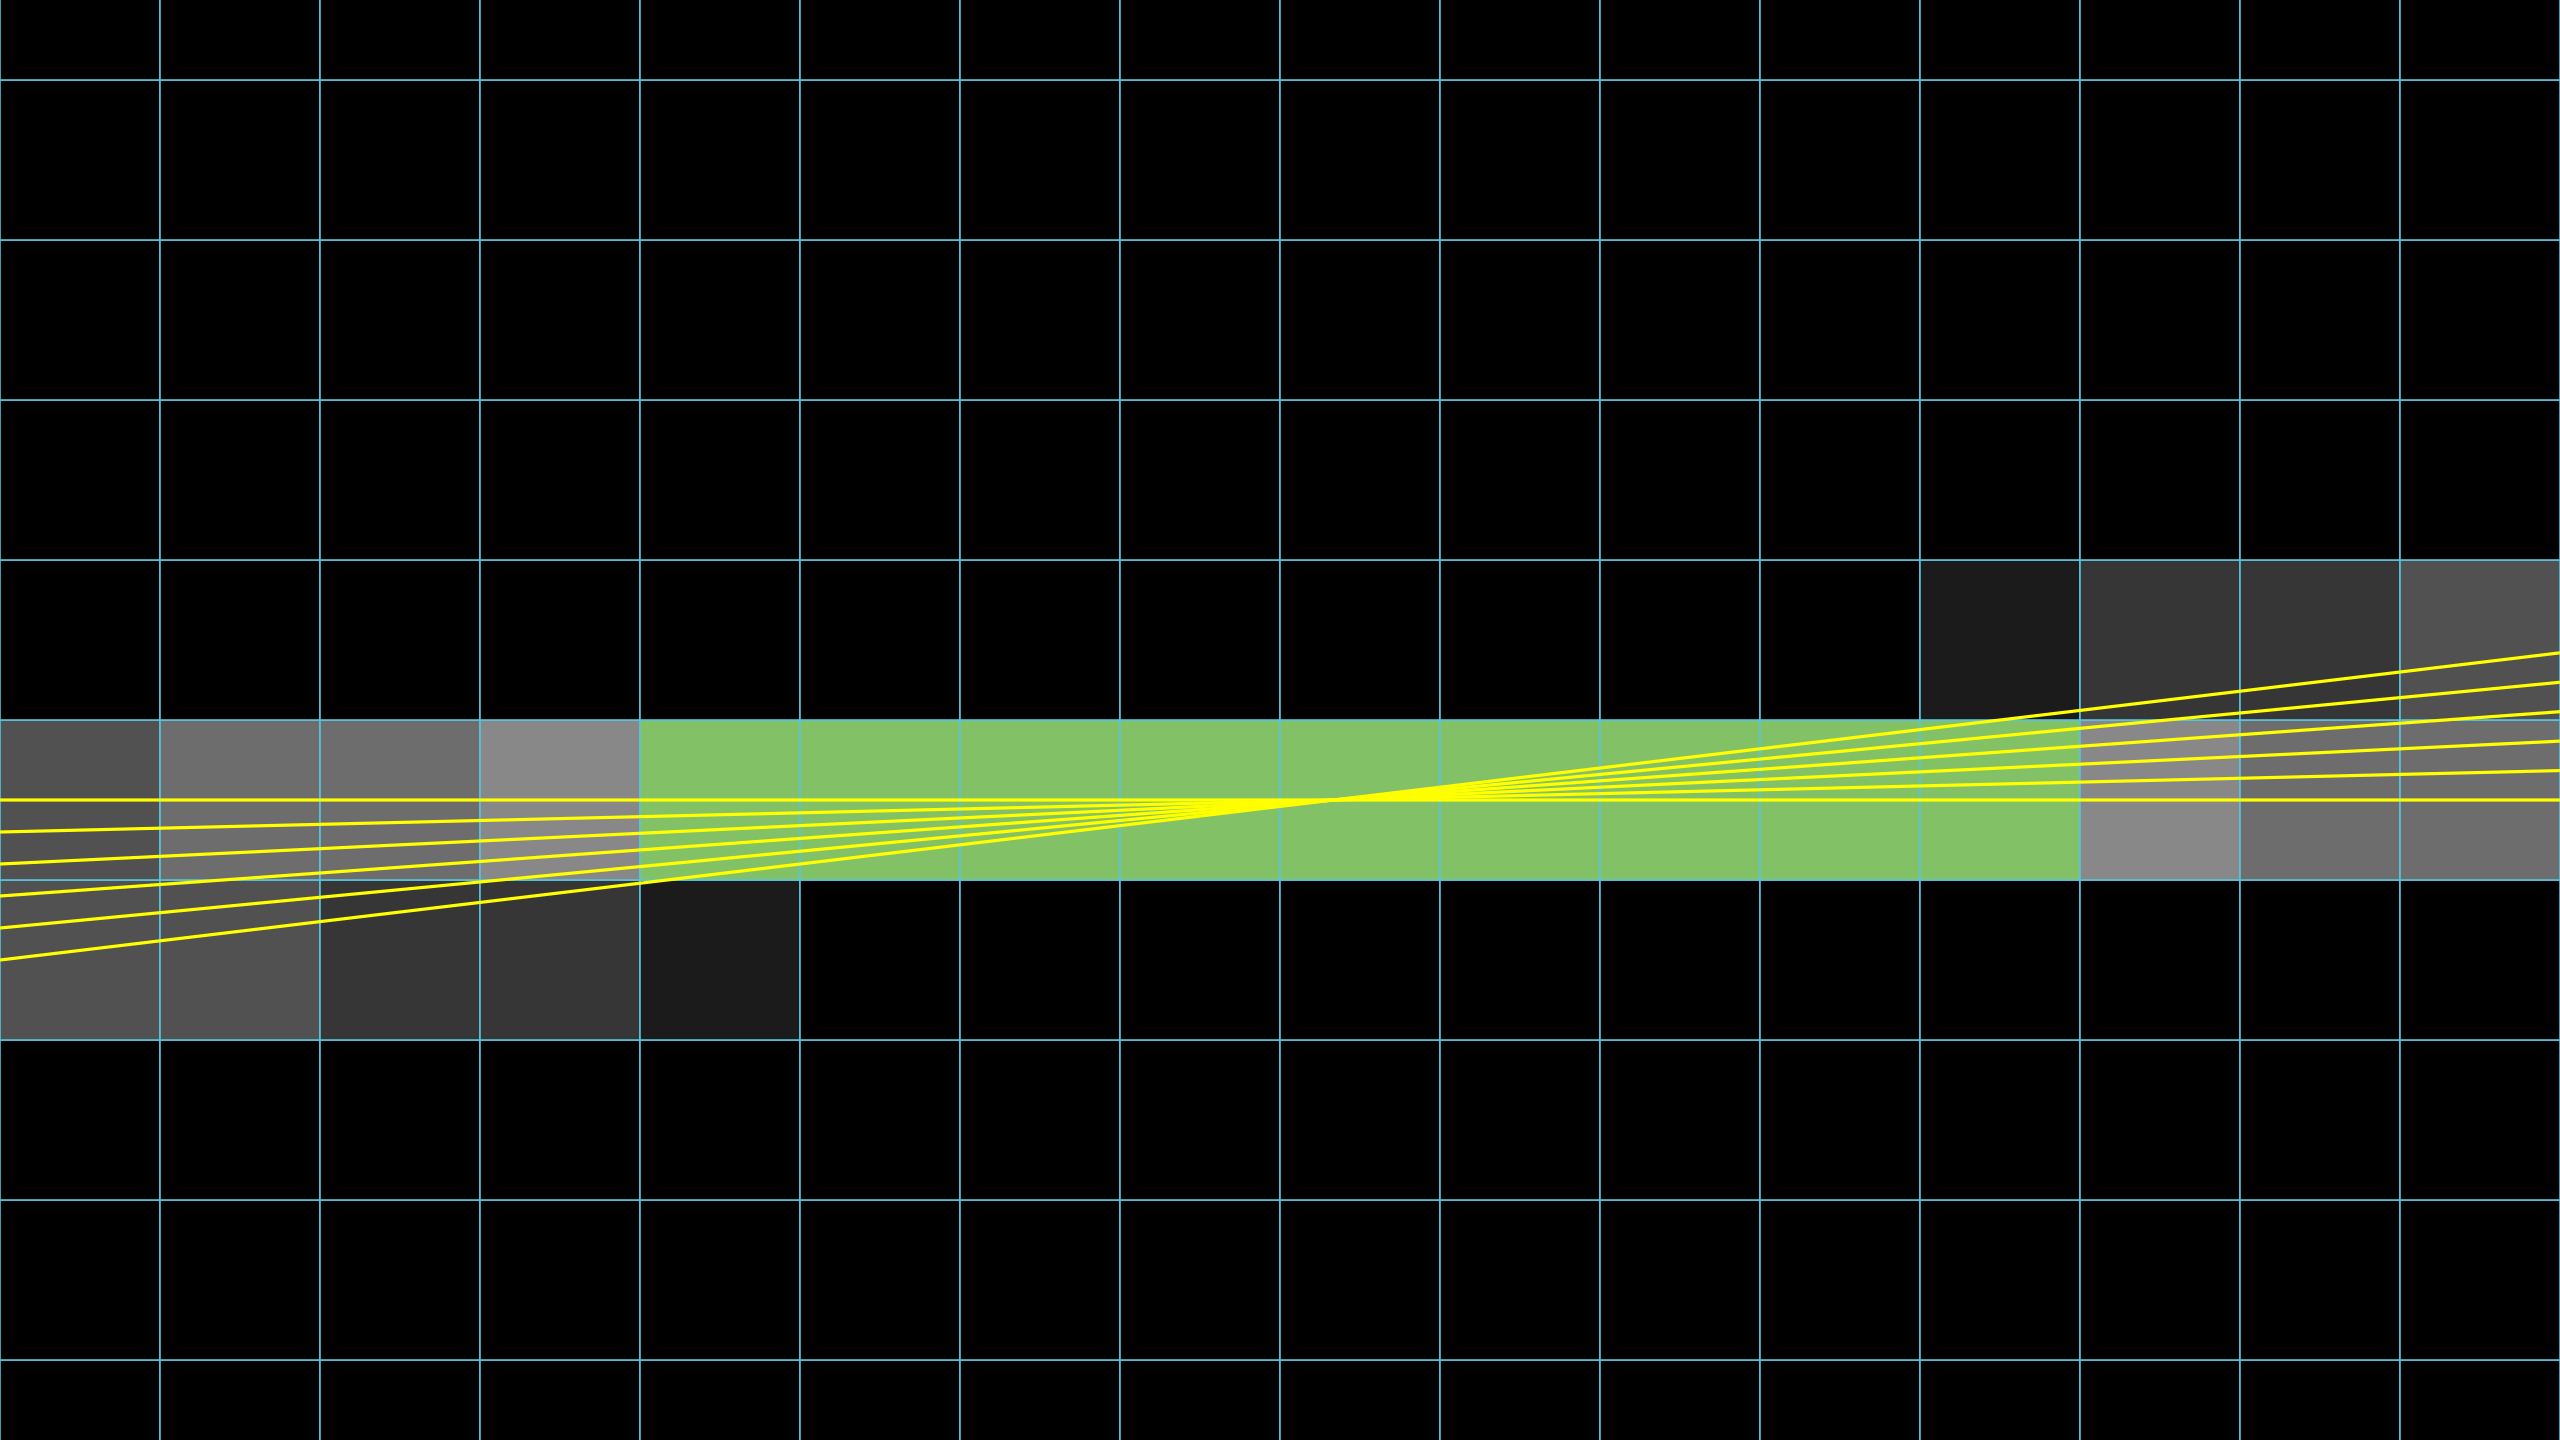

In [112]:
config.frame_width = 16
config.frame_height = 9

slope_multiplier = 0.024
intercept_multiplier = 0.2
points = [
    (0 * slope_multiplier, 5 * intercept_multiplier + 6.5),
    (1 * slope_multiplier, 4 * intercept_multiplier + 6.5),
    (2 * slope_multiplier, 3 * intercept_multiplier + 6.5),
    (3 * slope_multiplier, 2 * intercept_multiplier + 6.5),
    (4 * slope_multiplier, 1 * intercept_multiplier + 6.5),
    (5 * slope_multiplier, 0 * intercept_multiplier + 6.5)
]

accumulator_min_x = 0
accumulator_max_x = 16
accumulator_min_y = 0
accumulator_max_y = 16
accumulator_width = accumulator_max_x - accumulator_min_x
accumulator_height = accumulator_max_y - accumulator_min_y
hits_threshold = 5

traditional_accumulator = []
for x in range(accumulator_min_x, accumulator_max_x):
    for y in range(accumulator_min_y, accumulator_max_y):
        cell = Cell(x, x + 1, y, y + 1)
        hits = cell.get_hits(points, hough_transform_function)
        state = "solution" if len(hits) > hits_threshold else "discarded"
        cell.state = state
        traditional_accumulator.append(cell)

class AccumulatorWithPointsCloseToParallel(Scene):
    def construct(self):
        def create_cell_drawing(cell):
            rect = Rectangle(
                width=cell.x_max - cell.x_min,
                height=cell.y_max - cell.y_min,
                fill_color=GREEN if cell.state == "solution" else GRAY * min(cell.num_hits / hits_threshold, 1),
                fill_opacity=1,
                stroke_color=BLUE,
                stroke_width=1
            )
            rect.move_to(np.array([(cell.x_min + cell.x_max) / 2, (cell.y_min + cell.y_max) / 2, 0]))
            return rect
        
        # Traditional accumulator cells
        traditional_accumulator_group = VGroup()
        for cell in traditional_accumulator:
            traditional_accumulator_group.add(create_cell_drawing(cell))

        # Points
        def draw_points(points, group):
            for point in points:
                start_x = accumulator_min_x - accumulator_width * 0.1
                end_x = accumulator_max_x + accumulator_width * 0.1
                start = np.array([start_x, hough_transform_function(point, start_x), 0])
                end = np.array([end_x, hough_transform_function(point, end_x), 0])
                line = Line(start, end, color=YELLOW, stroke_width=2)
                group.add(line)

        draw_points(points, traditional_accumulator_group)

        scene_group = VGroup()
        traditional_accumulator_group.shift(np.array([-24, 0, 0]))
        scene_group.add(traditional_accumulator_group)

        scene_group.center()
        self.add(scene_group)

%manim -qh -r 2560,1440 -v WARNING AccumulatorWithPointsCloseToParallel

Manim Community v0.19.0

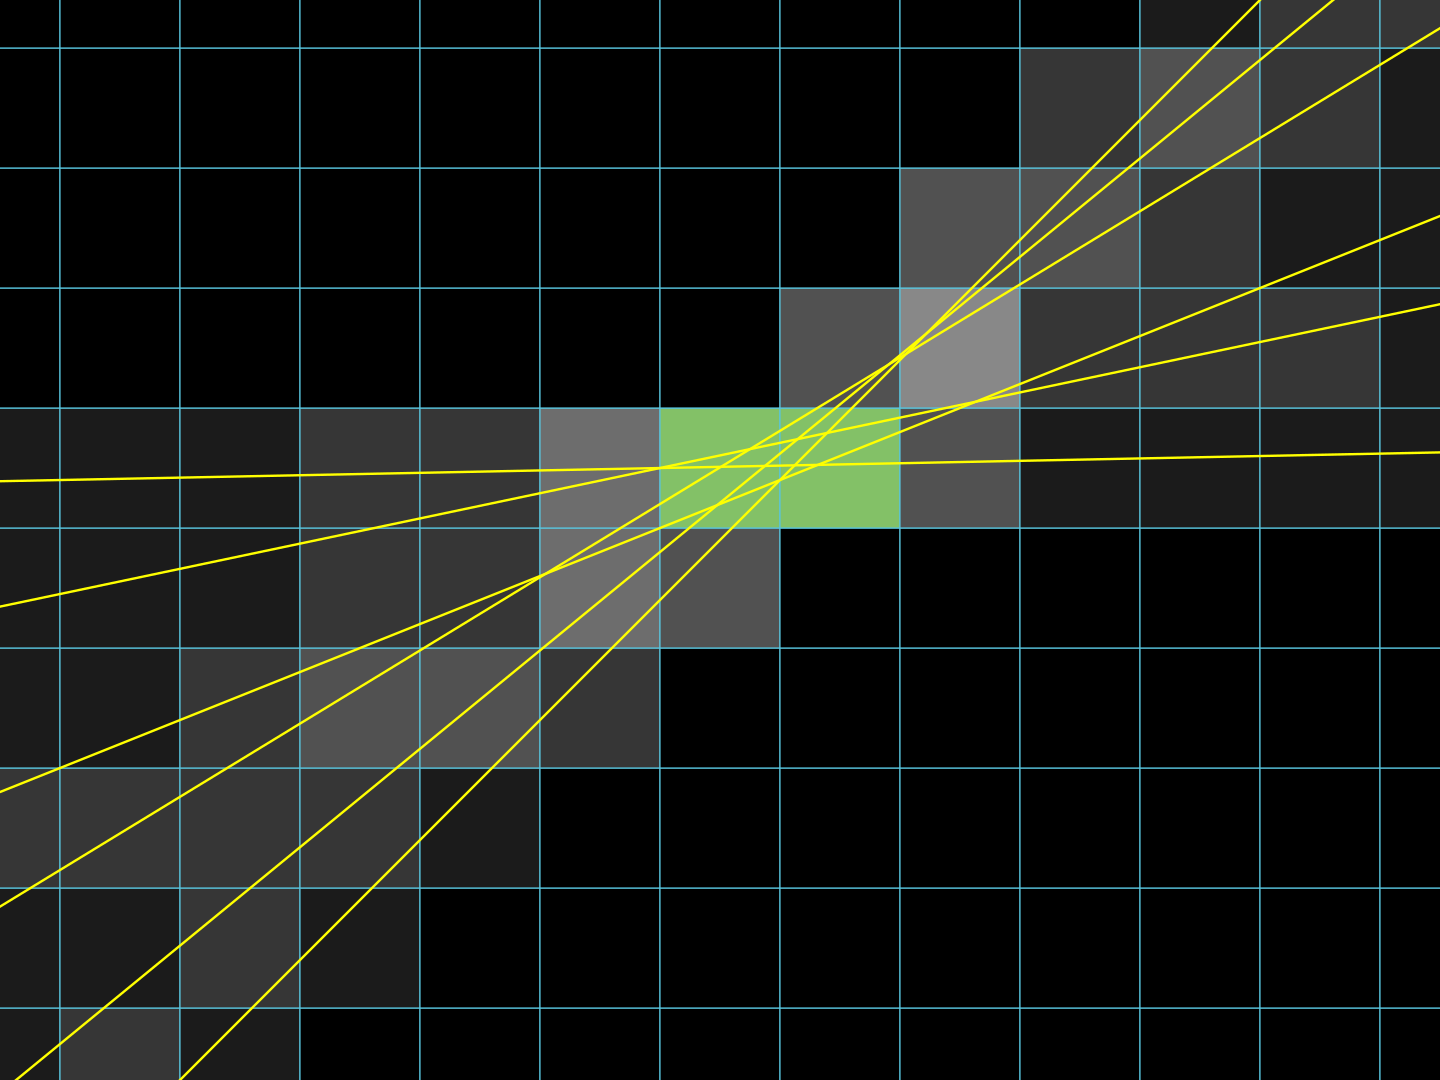

In [125]:
config.frame_width = 12
config.frame_height = 9

slope_multiplier = 0.2
intercept_multiplier = 0.2
points = [
    (0 * slope_multiplier + 0.02, 5 * intercept_multiplier + 0.5),
    (1 * slope_multiplier + 0.01, 4 * intercept_multiplier + 0.7),
    (2 * slope_multiplier + 0.00, 3 * intercept_multiplier + 0.4),
    (3 * slope_multiplier + 0.01, 2 * intercept_multiplier + 0.8),
    (4 * slope_multiplier + 0.02, 1 * intercept_multiplier + 0.6),
    (5 * slope_multiplier + 0.00, 0 * intercept_multiplier + 0.4)
]

accumulator_min_x = -8
accumulator_max_x = 9
accumulator_min_y = -8
accumulator_max_y = 8
accumulator_width = accumulator_max_x - accumulator_min_x
accumulator_height = accumulator_max_y - accumulator_min_y
hits_threshold = 5

traditional_accumulator = []
for x in range(accumulator_min_x, accumulator_max_x):
    for y in range(accumulator_min_y, accumulator_max_y):
        cell = Cell(x, x + 1, y, y + 1)
        hits = cell.get_hits(points, hough_transform_function)
        state = "solution" if len(hits) > hits_threshold else "discarded"
        cell.state = state
        traditional_accumulator.append(cell)

class CloudOfIntersectingLines(Scene):
    def construct(self):
        def create_cell_drawing(cell):
            rect = Rectangle(
                width=cell.x_max - cell.x_min,
                height=cell.y_max - cell.y_min,
                fill_color=GREEN if cell.state == "solution" else GRAY * min(cell.num_hits / hits_threshold, 1),
                fill_opacity=1,
                stroke_color=BLUE,
                stroke_width=1
            )
            rect.move_to(np.array([(cell.x_min + cell.x_max) / 2, (cell.y_min + cell.y_max) / 2, 0]))
            return rect
        
        # Traditional accumulator cells
        traditional_accumulator_group = VGroup()
        for cell in traditional_accumulator:
            traditional_accumulator_group.add(create_cell_drawing(cell))

        # Points
        def draw_points(points, group):
            for point in points:
                start_x = accumulator_min_x - accumulator_width * 0.1
                end_x = accumulator_max_x + accumulator_width * 0.1
                start = np.array([start_x, hough_transform_function(point, start_x), 0])
                end = np.array([end_x, hough_transform_function(point, end_x), 0])
                line = Line(start, end, color=YELLOW, stroke_width=2)
                group.add(line)

        draw_points(points, traditional_accumulator_group)

        scene_group = VGroup()
        traditional_accumulator_group.shift(np.array([-24, 0, 0]))
        scene_group.add(traditional_accumulator_group)

        scene_group.center()
        self.add(scene_group)

%manim -qh -r 1440,1080 -v WARNING CloudOfIntersectingLines

In [ ]:
config.frame_width = 12
config.frame_height = 9

slope_multiplier = 0.2
intercept_multiplier = 0.2
points = [
    (0 * slope_multiplier + 0.02, 5 * intercept_multiplier + 0.5),
    (1 * slope_multiplier + 0.01, 4 * intercept_multiplier + 0.7),
    (2 * slope_multiplier + 0.00, 3 * intercept_multiplier + 0.4),
    (3 * slope_multiplier + 0.01, 2 * intercept_multiplier + 0.8),
    (4 * slope_multiplier + 0.02, 1 * intercept_multiplier + 0.6),
    (5 * slope_multiplier + 0.00, 0 * intercept_multiplier + 0.4)
]

accumulator_min_x = -8
accumulator_max_x = 9
accumulator_min_y = -8
accumulator_max_y = 8
accumulator_width = accumulator_max_x - accumulator_min_x
accumulator_height = accumulator_max_y - accumulator_min_y
hits_threshold = 5

traditional_accumulator = []
for x in range(accumulator_min_x, accumulator_max_x):
    for y in range(accumulator_min_y, accumulator_max_y):
        cell = Cell(x, x + 1, y, y + 1)
        hits = cell.get_hits(points, hough_transform_function)
        state = "solution" if len(hits) > hits_threshold else "discarded"
        cell.state = state
        traditional_accumulator.append(cell)

class CloudOfIntersectingLines(Scene):
    def construct(self):
        def create_cell_drawing(cell):
            rect = Rectangle(
                width=cell.x_max - cell.x_min,
                height=cell.y_max - cell.y_min,
                fill_color=GREEN if cell.state == "solution" else GRAY * min(cell.num_hits / hits_threshold, 1),
                fill_opacity=1,
                stroke_color=BLUE,
                stroke_width=1
            )
            rect.move_to(np.array([(cell.x_min + cell.x_max) / 2, (cell.y_min + cell.y_max) / 2, 0]))
            return rect
        
        # Traditional accumulator cells
        traditional_accumulator_group = VGroup()
        for cell in traditional_accumulator:
            traditional_accumulator_group.add(create_cell_drawing(cell))

        # Points
        def draw_points(points, group):
            for point in points:
                start_x = accumulator_min_x - accumulator_width * 0.1
                end_x = accumulator_max_x + accumulator_width * 0.1
                start = np.array([start_x, hough_transform_function(point, start_x), 0])
                end = np.array([end_x, hough_transform_function(point, end_x), 0])
                line = Line(start, end, color=YELLOW, stroke_width=2)
                group.add(line)

        draw_points(points, traditional_accumulator_group)

        scene_group = VGroup()
        traditional_accumulator_group.shift(np.array([-24, 0, 0]))
        scene_group.add(traditional_accumulator_group)

        scene_group.center()
        self.add(scene_group)

%manim -qh -r 1440,1080 -v WARNING CloudOfIntersectingLines

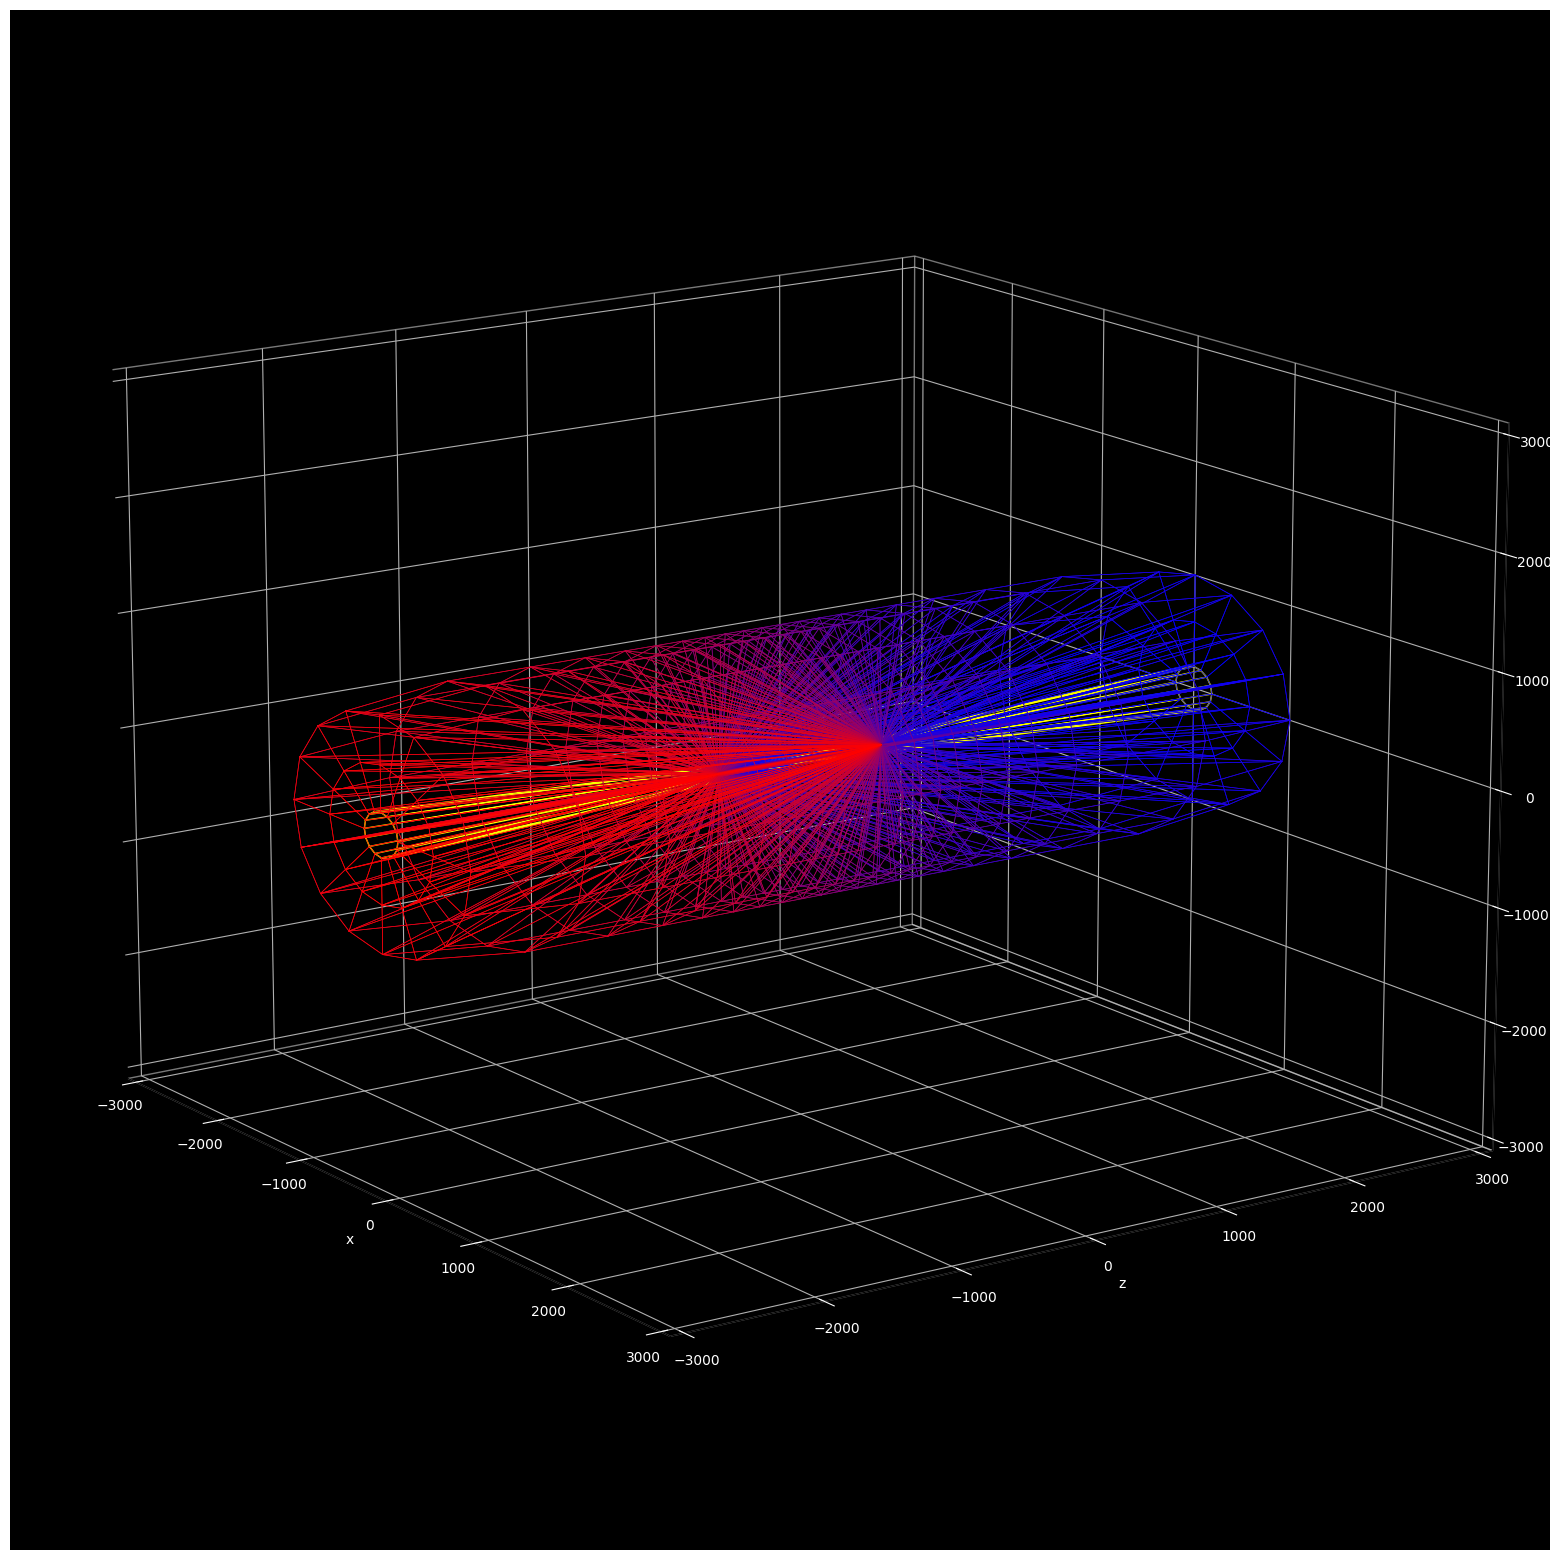

In [17]:
def get_wedges(num_z_ranges, num_x_ranges, min_x_angle, interaction_region_width, x_margin=0, z_margin=0):
    z_ranges = [(angle_wrap_2pi(i[0]), angle_wrap_2pi(i[1])) for i in uniform_range_split(num_z_ranges, 0, 2 * math.pi, z_margin)]
    x_ranges = uniform_range_split(num_x_ranges, min_x_angle, math.pi - min_x_angle, x_margin)

    wedges = []
    for x_range in x_ranges:
        for z_range in z_ranges:
            wedges.append(Wedge(z_range[0], z_range[1], x_range[0], x_range[1], interaction_region_width))
    return wedges

def get_pole_regions(max_x_angle, interaction_region_width, margin=0):
    return [
        PoleRegion(max_x_angle + margin, interaction_region_width),
        PoleRegion(math.pi - max_x_angle - margin, interaction_region_width)
    ]

num_z_ranges = 16
num_x_ranges = 24
min_x_angle = 5 / 256 * math.pi
interaction_region_width = 2 * 0.2 * 3100
# x_margin = 1 / 128 * math.pi
# z_margin = 1 / 32 * math.pi
x_margin = 0
z_margin = 0

wedges = get_wedges(num_z_ranges, num_x_ranges, min_x_angle, interaction_region_width, x_margin, z_margin)
pole_regions = get_pole_regions(min_x_angle, interaction_region_width, x_margin)

perspectives = []
# perspectives.append({'elev': 0, 'azim': 0, 'roll': 0})
# perspectives.append({'elev': 0, 'azim': 270, 'roll': 0})
perspectives.append({'elev': 15, 'azim': -35, 'roll': 0})
for perspective in perspectives:
    detector_plot = DetectorPlot(keep_aspect_ratio=True, perspective=perspective, figure_size=(20, 20))
    for pole_region in pole_regions:
        detector_plot.plot_pole_region(pole_region, num_rays=num_z_ranges, color='yellow')
    for i in range(len(wedges)):
        # if i % 15 != 0:
        #     continue
        red = (i / (len(wedges) - 1))
        blue = 1 - red
        detector_plot.plot_wedge(wedges[i], color=(red, 0, blue), linewidth=0.5)

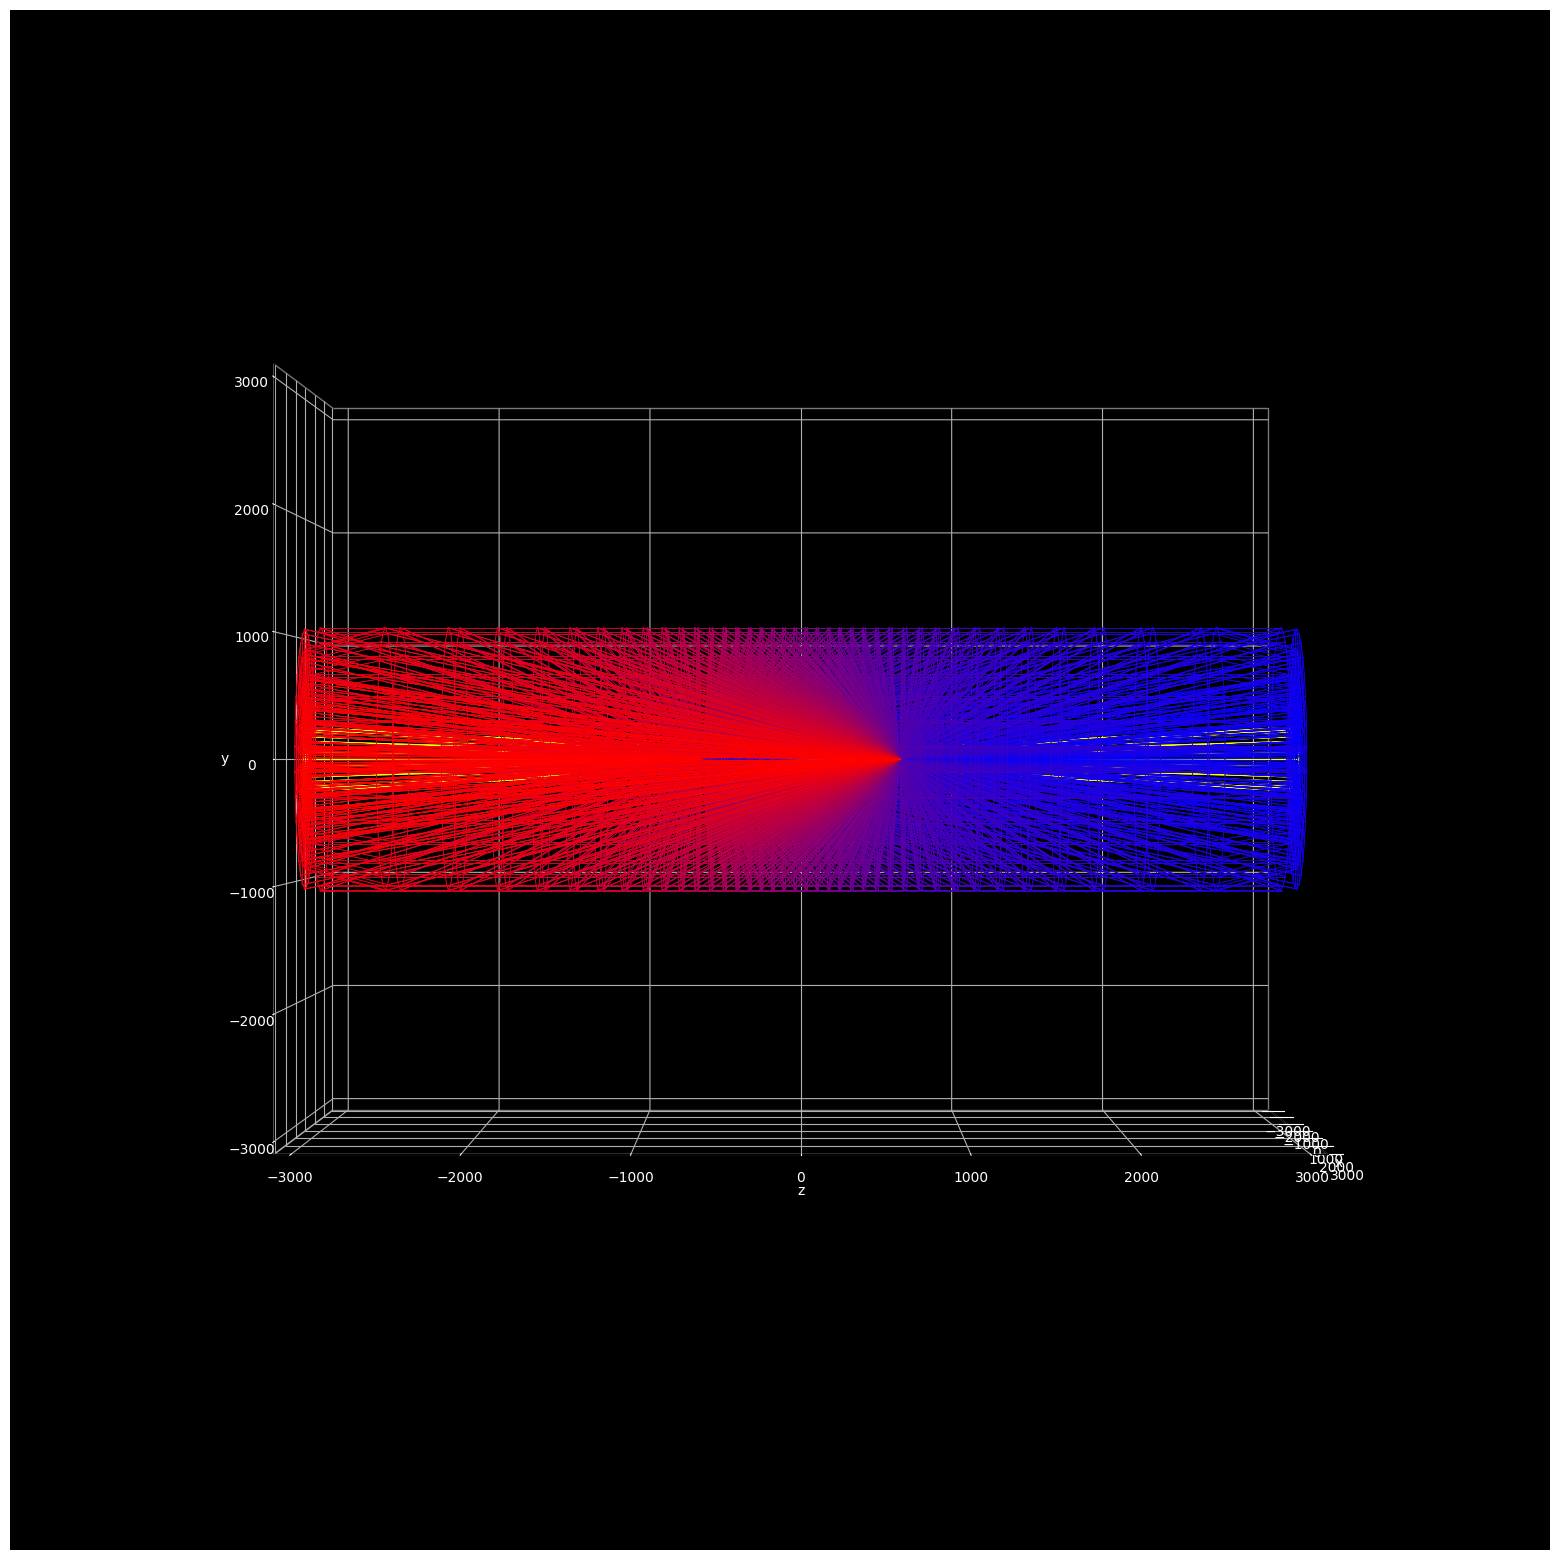

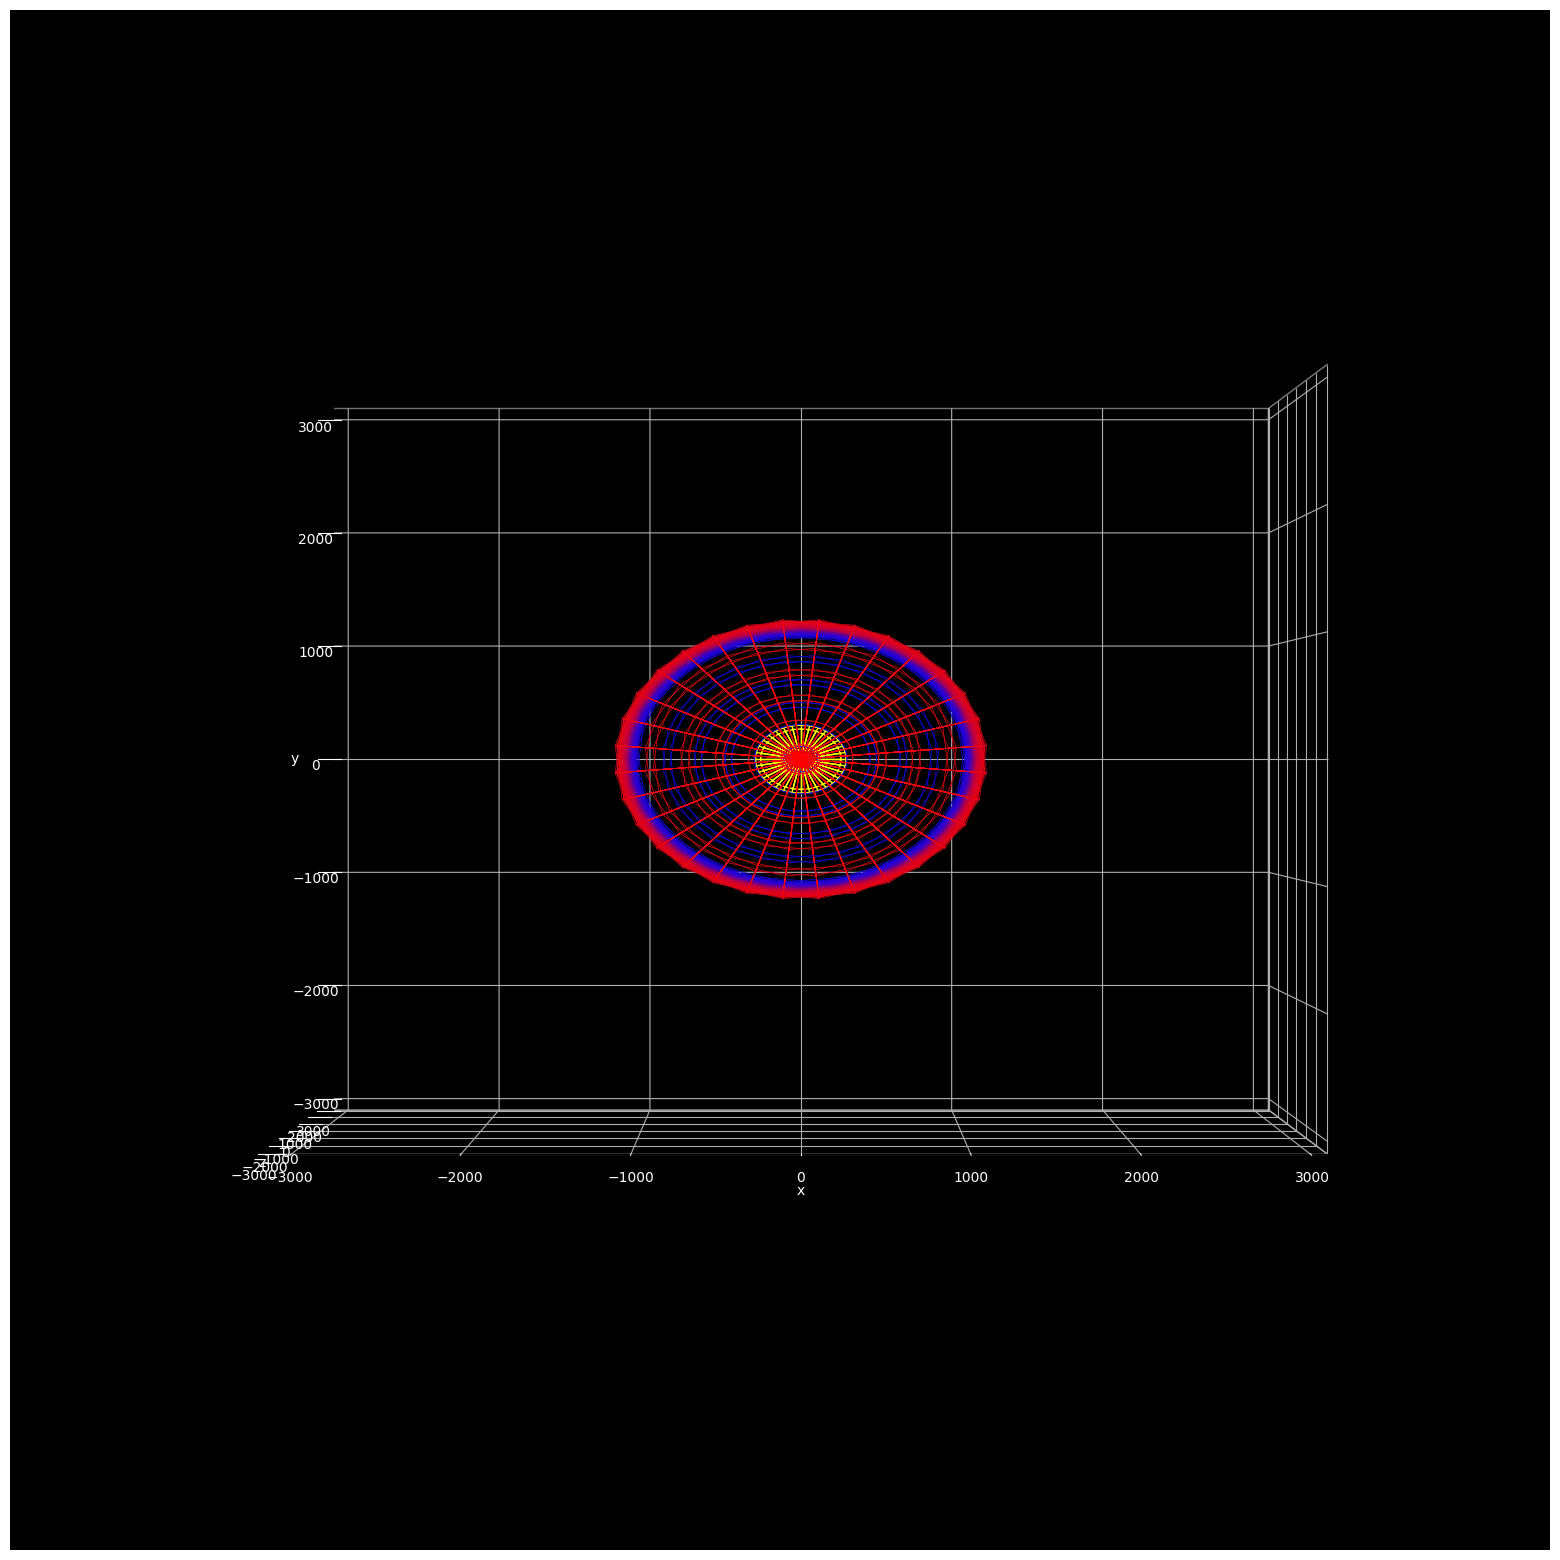

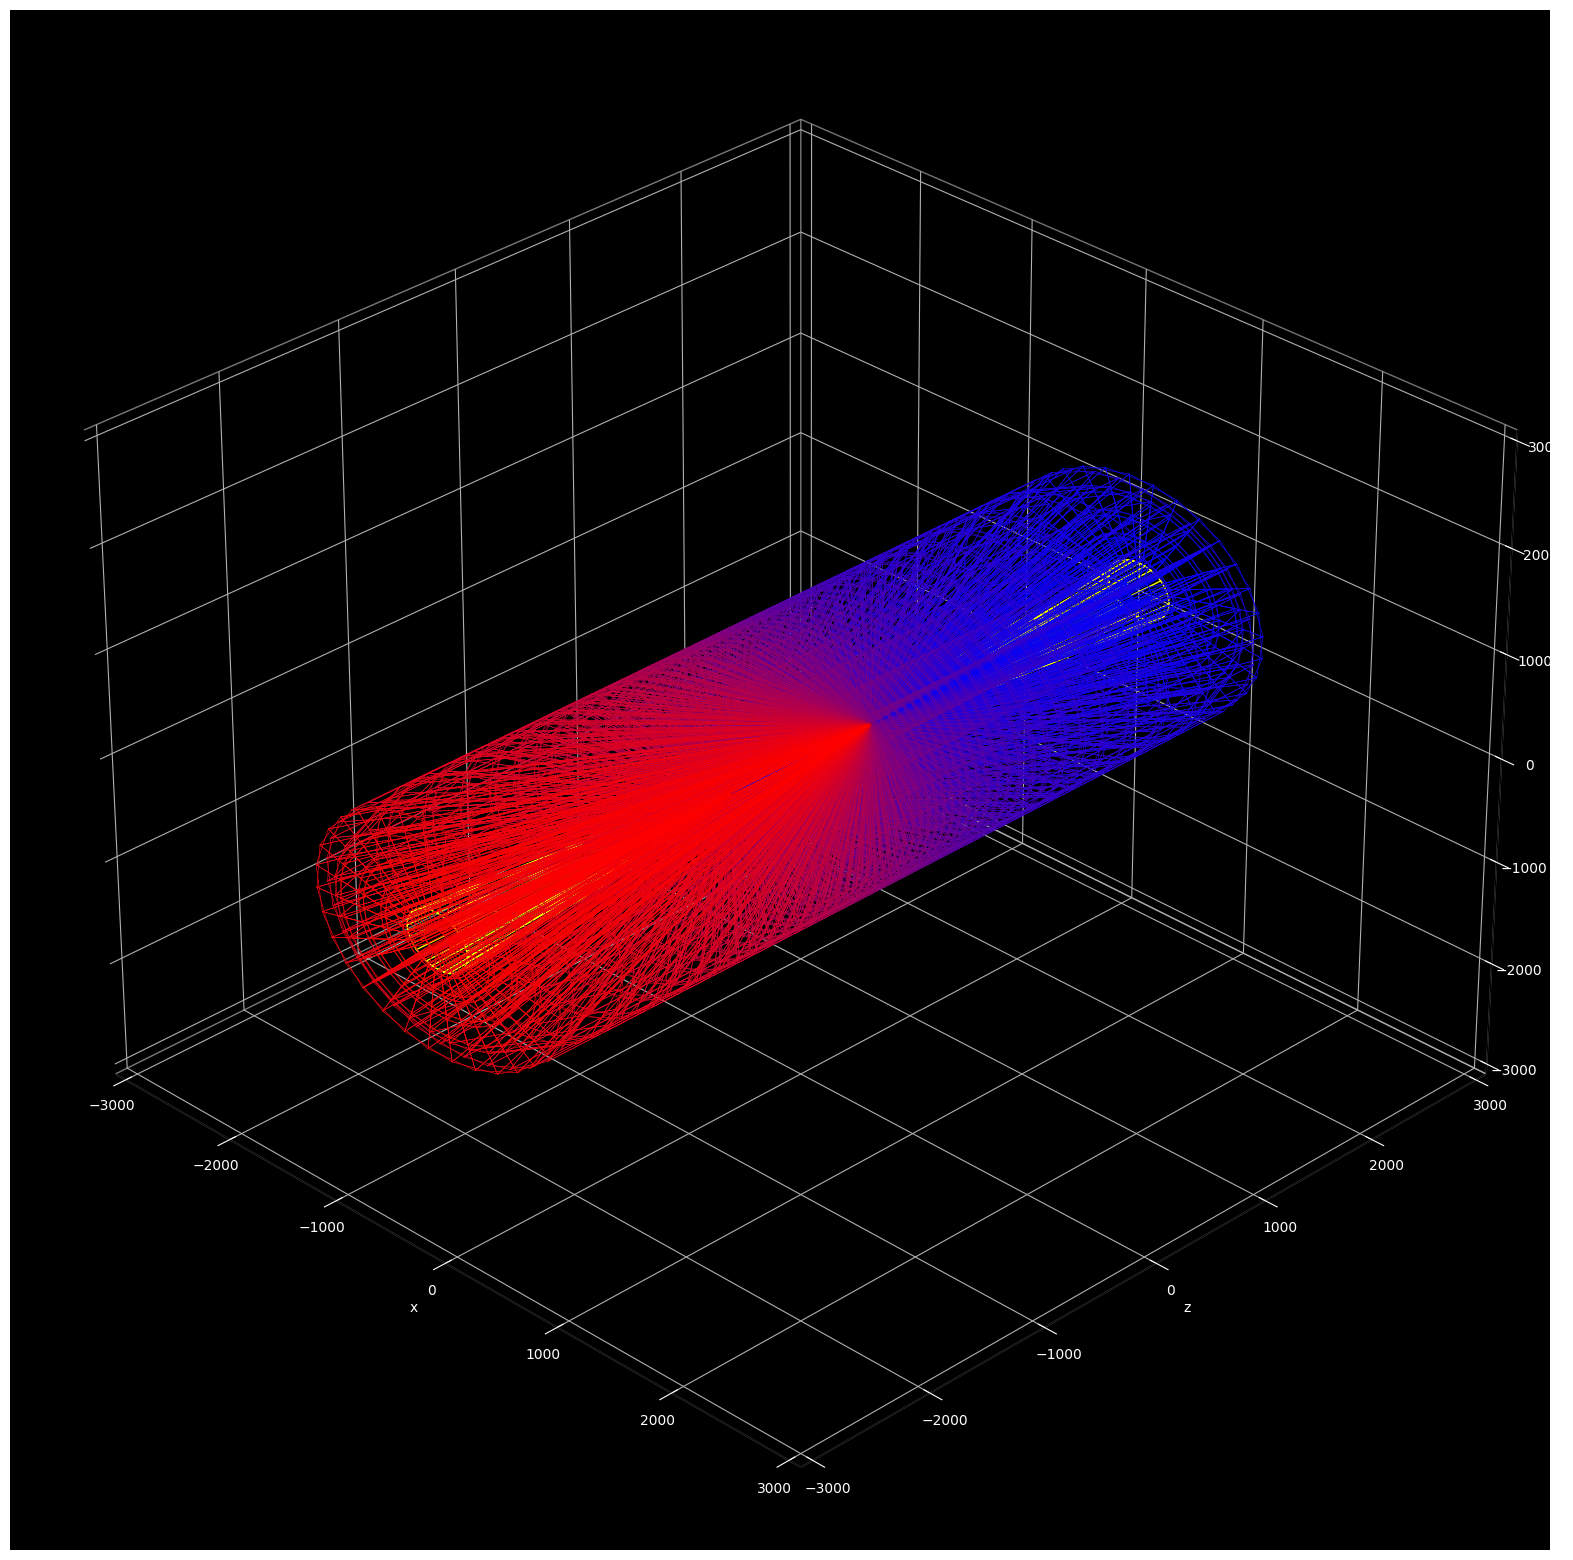

In [39]:
def get_wedges(num_z_ranges, num_x_ranges, min_x_angle, interaction_region_width, x_margin=0, z_margin=0):
    z_ranges = [(angle_wrap_2pi(i[0]), angle_wrap_2pi(i[1])) for i in uniform_range_split(num_z_ranges, 0, 2 * math.pi, z_margin)]
    x_ranges = uniform_range_split(num_x_ranges, min_x_angle, math.pi - min_x_angle, x_margin)

    wedges = []
    for x_range in x_ranges:
        for z_range in z_ranges:
            wedges.append(Wedge(z_range[0], z_range[1], x_range[0], x_range[1], interaction_region_width))
    return wedges

def get_pole_regions(max_x_angle, interaction_region_width, margin=0):
    return [
        PoleRegion(max_x_angle + margin, interaction_region_width),
        PoleRegion(math.pi - max_x_angle - margin, interaction_region_width)
    ]

num_z_ranges = 32
num_x_ranges = 48
min_x_angle = 5 / 256 * math.pi
interaction_region_width = 2 * 0.2 * 3100
x_margin = 1 / 128 * math.pi
z_margin = 1 / 32 * math.pi
# x_margin = 0
# z_margin = 0

wedges = get_wedges(num_z_ranges, num_x_ranges, min_x_angle, interaction_region_width, x_margin, z_margin)
pole_regions = get_pole_regions(min_x_angle, interaction_region_width, x_margin)

perspectives = []
perspectives.append({'elev': 0, 'azim': 0, 'roll': 0})
perspectives.append({'elev': 0, 'azim': 270, 'roll': 0})
perspectives.append({'elev': 30, 'azim': -45, 'roll': 0})
for perspective in perspectives:
    detector_plot = DetectorPlot(keep_aspect_ratio=True, perspective=perspective, figure_size=(20, 20))
    for pole_region in pole_regions:
        detector_plot.plot_pole_region(pole_region, num_rays=num_z_ranges, color='yellow')
    for i in range(len(wedges)):
        red = (i / (len(wedges) - 1))
        blue = 1 - red
        detector_plot.plot_wedge(wedges[i], color=(red, 0, blue), linewidth=0.5)